# Autoencoder for Profiling Network Device Communication from TLS Flow Attributes

This notebook implements experiments with a convolutional **autoencoder** designed to model and profile encrypted network communication based on **TLS flow metadata**.  
It is part of the research presented in *"Towards Federated Autoencoder Profiling of Encrypted Network Communication"*.

### Overview
This version extends the previous implementation by incorporating **new TLS attributes and enriched feature values**, enabling more accurate modeling of device-specific and application-level traffic patterns.  
The notebook also supports **cross-validation across multiple devices**, allowing comparative evaluation of communication profiles.

### Included Features and Updates
- **ALPN** – Application-Layer Protocol Negotiation identifiers  
- **CSV** – Client Supported Versions  
- **SEXT** – Server Extensions (including `'0005'`)  
- **CCS** – Client Cipher Suites (including `'003C'`, `'003D'`, `'C023'`, `'C024'`, `'C027'`, `'C028'`)  
- **SSV** – Server Supported Versions  

These features improve the representation of TLS handshake diversity, providing richer context for profiling and anomaly detection tasks.

## Environment Setup and Library Installation

To keep dependencies isolated and avoid version conflicts, it is recommended to create and activate a virtual environment before installing the libraries.
Before running this notebook, ensure that all required Python libraries are available in your environment.  
The following commands install the necessary packages for data processing, model training, and visualization:

In [1]:
!pip install matplotlib
!pip install tensorflow
!pip install scikit-learn
!pip install pandas
!pip install numpy
!pip install seaborn

## Global configuration

In [2]:
dataset_root = "../datasets"

import sys
sys.path.append('../lib')

# Dataset Preparation

The data are read from all samples in the given folder (eg., desktop applications). From the source JSON we extract only the following (numerical) features:

* Flow Data: A subset of columns that contain numerical flow metrics ('BytesOut', 'PacketsOut', 'BytesIn', 'PacketsIn', 'Duration') is extracted from the DataFrame. These values are converted to a NumPy array of type float32.
* TLS Records size sequence: The 'RecordSequence' column, which holds sequences (arrays) of integers is taken and the array is padded or truncated so that its length is exactly RECORD_SEQUENCE_SIZE (20). These values are converted to a NumPy array of type float32.

The processed numerical flow data and the padded record sequences are concatenated horizontally (column-wise) such that each row has exactly 25 columns. Any NaN values in the concatenated dataset are replaced with 0.

For each column in the dataset, the minimum and maximum values are computed. A min-max normalization is then applied column-wise. This rescales every value so that each feature (column) lies in the range [0,1].

`normal_df` is prepared and can be used for the autoencoder training.

In [4]:
import json
import glob
import pandas as pd
import numpy as np
from array import array
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler 
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

RECORD_SEQUENCE_SIZE=20
tls_columns_names = np.array([f"tls.rec.{i}" for i in range(RECORD_SEQUENCE_SIZE)])

# Resize row in the array
def resize_row(row, maxlen, pad_value=0):
    current_length = len(row)
    if current_length < maxlen:
        # Calculate the amount of padding needed
        pad_width = maxlen - current_length
        # Pad at the end (you can also pad at the beginning or both sides)
        row = np.pad(row, pad_width=(0, pad_width), mode='constant', constant_values=pad_value)
    else:
        # If the row is longer than the target length, slice it
        row = row[:maxlen]
    return row
# Resize the matrix by padding or removing columns
def pad_sequences(rows, maxlen, pad_value=0):
    resized_rows = [resize_row(row, maxlen) for row in rows]
    return resized_rows

# Loads data from the specified collection of json files. It provides raw data.
def load_json_files(json_files):
    all_data = []
    # Open the file and read each line
    for filename in json_files:
        with open(filename, "r") as file:
            # Use a list comprehension to load each line as a JSON object
            data = [json.loads(line.strip()) for line in file]
            for item in data: all_data.append(item)
    # Convert the list of dictionaries into a DataFrame
    df = pd.DataFrame(all_data)
    df_filtered = df[df['tls.ja3s'] != '']
    return df_filtered

# Extracts features from raw dataset. This will provide suitable output to the preprocessing pipeline.
# Flow related columns: 'BytesOut', 'PacketsOut', 'BytesIn', 'PacketsIn', 'Duration'
# TLS handshake columns: 'TlsClientVersion','TlsServerVersion','TlsServerCipherSuite'
# TLS handshake columns transformed with MultiLabelBinarizer: TlsServerExtensions, TlsClientCipherSuites,
#     TlsClientExtensions, TlsClientSupportedGroups, TlsALPN, TlsClinetSupportedVersions,
#     TlsServerSupportedVerions, 
# TLS record sizes: 'RecordSequence' mapped as 'TlsRecord_X'
#
# The output is a DataFrame with the above specified columns. This dataframe can be used as the input to next
# processing block (preprocessor).
#
def extract_features(df):
    # Flow data
    flow_data = df[['bs', 'ps', 'br', 'pr', 'td']].astype(float)
    # TLS handshake data
    tls_data = df[['tls.cver','tls.sver','tls.scs']].fillna(0).astype(str) 
    # Other TLS attributes - fields of values transformed with MiltiLabelBinarizer
    #selected values are based on the most frequent values in tested datasets
    #tls.sext
    df['tls.sext'] = df['tls.sext'].apply(
    lambda x: x if isinstance(x, list) else ([] if pd.isna(x) else [x])
    )
    sext_possible_values = ['0000','0005','0010','0017','0023','0033','000B','002B','FF01']
    mlb = MultiLabelBinarizer(classes = sext_possible_values)
    mlb.fit([])
    transformed = mlb.transform(df['tls.sext'])
    tls_sext_mlb = pd.DataFrame(transformed,columns=mlb.classes_)
    print(mlb.classes_)
   
    # tls.ccs
    df['tls.ccs'] = df['tls.ccs'].apply(
    lambda x: x if isinstance(x, list) else ([] if pd.isna(x) else [x])
    )
    ccs_possible_values = ['0004','0005','0032','0033','0035','0038','0039','1301','1302','1303','000A',
                           '002F','003C','003D','009C','009D','009E','009F','00FF','C007','C009','C00A','C011','C013',
                           'C014','C023','C024','C027','C028','C02B','C02C','C02F','C030','CC13','CC14','CC15','CCA8','CCA9']
    mlb2 = MultiLabelBinarizer(classes = ccs_possible_values)
    mlb2.fit([])
    transformed2 = mlb2.transform(df['tls.ccs'])
    tls_ccs_mlb = pd.DataFrame(transformed2,columns=mlb2.classes_)
    tls_ccs_mlb_renamed = tls_ccs_mlb.add_suffix('_ccs')

    # tls.cext
    df['tls.cext'] = df['tls.cext'].apply(
    lambda x: x if isinstance(x, list) else ([] if pd.isna(x) else [x])
    )
    cext_possible_values = ['0000','0005','0010','0012','0015','0017','0023','0033','3374',
                            '4469','000A','000B','000D','001B','002B','002D','FE0D','FF01']
    mlb2 = MultiLabelBinarizer(classes = cext_possible_values)
    mlb2.fit([])
    transformed2 = mlb2.transform(df['tls.cext'])
    tls_cext_mlb = pd.DataFrame(transformed2,columns=mlb2.classes_)
    tls_cext_mlb_renamed = tls_cext_mlb.add_suffix('_cext')

    #  tls.csg
    df['tls.csg'] = df['tls.csg'].apply(
    lambda x: x if isinstance(x, list) else ([] if pd.isna(x) else [x])
    )
    csg_possible_values = ['0201','0202','0203','0301','0303','0401','0403','0501','0503',
                           '0601','0603','0804','0805','0806','0302','0402','0502','0602']
    mlb2 = MultiLabelBinarizer(classes = csg_possible_values)
    mlb2.fit([])
    transformed2 = mlb2.transform(df['tls.csg'])
    tls_csg_mlb = pd.DataFrame(transformed2,columns=mlb2.classes_)
    tls_csg_mlb_renamed = tls_csg_mlb.add_suffix('_csg')

    # tls.alpn
    df['tls.alpn'] = df['tls.alpn'].apply(
    lambda x: x if isinstance(x, list) else ([] if pd.isna(x) else [x])
    )
    alpn_possible_values = ['h2','http/1.1','']
    mlb2 = MultiLabelBinarizer(classes = alpn_possible_values)
    mlb2.fit([])
    transformed2 = mlb2.transform(df['tls.alpn'])
    tls_alpn_mlb = pd.DataFrame(transformed2,columns=mlb2.classes_)
    tls_alpn_mlb_renamed = tls_alpn_mlb.add_suffix('_alpn')
    
    # tls.csv
    df['tls.csv'] = df['tls.csv'].apply(
    lambda x: x if isinstance(x, list) else ([] if pd.isna(x) else [x])
    )
    csv_possible_values = ['0303','0304','']
    mlb2 = MultiLabelBinarizer(classes = csv_possible_values)
    mlb2.fit([])
    transformed2 = mlb2.transform(df['tls.csv'])
    tls_csv_mlb = pd.DataFrame(transformed2,columns=mlb2.classes_)
    tls_csv_mlb_renamed = tls_csv_mlb.add_suffix('_csv')
    
    # tls.ssv
    df['tls.ssv'] = df['tls.ssv'].apply(
    lambda x: x if isinstance(x, list) else ([] if pd.isna(x) else [x])
    )
    ssv_possible_values = ['0304','']
    mlb2 = MultiLabelBinarizer(classes = ssv_possible_values)
    mlb2.fit([])
    transformed2 = mlb2.transform(df['tls.ssv'])
    tls_ssv_mlb = pd.DataFrame(transformed2,columns=mlb2.classes_)
    tls_ssv_mlb_renamed = tls_ssv_mlb.add_suffix('_ssv')
    
    #zde pridat sloupce i pro dalsi seznamy hodnot
    # TLS records 
    records_data = pd.DataFrame( pad_sequences(df['tls.rec'].values, maxlen=RECORD_SEQUENCE_SIZE), columns=tls_columns_names)
    dataset = pd.concat([flow_data, tls_data, tls_sext_mlb, tls_ccs_mlb_renamed, tls_cext_mlb_renamed, 
                         tls_csg_mlb_renamed, tls_alpn_mlb_renamed, tls_csv_mlb_renamed, tls_ssv_mlb_renamed, records_data], axis=1).fillna(0)
    print(dataset.shape)    
    return dataset
#
# Fits the preprocessor that contains scalers for numerical features and OneHotEncoder for categorical data.
# The result is the Pipeline that can be used for further data processing before they are fed in the Autoencoder.
# 
def fit_preprocessor(df):
    preprocessor = ColumnTransformer(
        transformers=[
            ('num_tls', MinMaxScaler(), tls_columns_names),
            ('num_flow', MinMaxScaler(), ['bs', 'ps', 'br', 'pr', 'td']),           
            ('cat1', OneHotEncoder(categories = [['0303','0301','0300','0302','']], sparse_output=False, handle_unknown='ignore'), ['tls.cver']),
            ('cat2', OneHotEncoder(categories = [['0303','0301','0300','0302','']], sparse_output=False, handle_unknown='ignore'),['tls.sver']),
            ('cat3', OneHotEncoder(categories = [['', '0xc02b', '0xc02f', '0xcc14', '0xcc13', '0xc030', '0xc014',
                                                       '0x0033', '0x0035', '0x009c', '0xc013', '0x0005', '0x009e',
                                                       '0x002f', '0x000a', '0xcca9', '0xcca8', '0x009f', '0xc011',
                                                       '0xc028', '0x009d', '0x0039', '0x1301', '0x1302', '0xc02c',
                                                       '0x003c', '0xc009', '0x0004', '0xc027', '0x003d', '0x0067']], 
                                    sparse_output=False, handle_unknown='ignore'),['tls.scs']),
            ('remaining', 'passthrough', [])         
        ], remainder='passthrough')
    pipeline = Pipeline(steps=[('preprocessor', preprocessor)])
    pipeline.fit(df)
    return pipeline


# -------------------------------------------------
# Load normal data and prepare them for Autoencoder
# Normal data are for now represented as the desktop application communication.
#
raw_df = load_json_files(glob.glob(f"{dataset_root}/BUT-SOHO2025/192.168.1.198/*.ndjson"))  #homelan.tls/192.168.1.169/
print(f'dataset shape={raw_df.shape}')

raw_df = raw_df.rename(columns={'te': 'td'}) #needed for homelan datasets - different column name
input_df = extract_features(raw_df)

pipeline = fit_preprocessor(input_df)
normal_df = pipeline.transform(input_df)

print('Normalized row of data:')
print(normal_df[0])

normal_pandas_df = pd.DataFrame(normal_df)
print(normal_pandas_df.head())

print(f'dataset shape={normal_df.shape}')


dataset shape=(46400, 25)
['0000' '0005' '0010' '0017' '0023' '0033' '000B' '002B' 'FF01']


d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['0029'] will be ignored
  warnings.warn(
d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['0067', '006B', '0A0A', '1A1A', '2A2A', '3A3A', '4A4A', '5A5A', '6A6A', '7A7A', '8A8A', '9A9A', 'AAAA', 'BABA', 'CACA', 'CCAA', 'DADA', 'EAEA', 'FAFA'] will be ignored
  warnings.warn(
d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['0016', '0029', '002A', '0A0A', '1A1A', '2A2A', '3A3A', '44CD', '4A4A', '5A5A', '6A6A', '7A7A', '8A8A', '9A9A', 'AAAA', 'BABA', 'CACA', 'DADA', 'EAEA', 'FAFA', 'FF04'] will be ignored
  warnings.warn(
d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['0807', '0808', '0809', '080A', '080B'] will be ignored
  warnings.warn(
d:\GitHub\AutoFedProfile\.ve

(46400, 119)
Normalized row of data:
[7.50312110e-01 1.00022227e-02 1.04417671e-01 2.41334014e-01
 3.08363971e-01 4.25304878e-01 8.89121256e-01 4.97790240e-01
 4.98643665e-01 4.98917980e-01 4.98978939e-01 5.02880307e-01
 5.01630650e-01 4.58410802e-01 2.86133804e-01 4.99100856e-01
 4.99893322e-01 4.99893322e-01 4.99893322e-01 4.99893322e-01
 2.34709915e-05 2.09663141e-04 9.71931466e-05 2.44738130e-04
 7.81689550e-07 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 1.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.

# Autoencoder Training

The autoencoder is trained on `normal_df`. The data are split into training (80%) and testing (20%) parts. The size of laten space is set to `LATENT_SPACE_SIZE`.

The results are visualzied for the 10 selected sample. 

Read more: https://www.tensorflow.org/tutorials/generative/autoencoder

k-fold cross-validation used for training and subsequent testing

Validation set indices: [    0    10    20 ... 46370 46380 46390]
Validation set indices: [    1    11    21 ... 46371 46381 46391]
Validation set indices: [    2    12    22 ... 46372 46382 46392]
Validation set indices: [    3    13    23 ... 46373 46383 46393]
Validation set indices: [    4    14    24 ... 46374 46384 46394]
Validation set indices: [    5    15    25 ... 46375 46385 46395]
Validation set indices: [    6    16    26 ... 46376 46386 46396]
Validation set indices: [    7    17    27 ... 46377 46387 46397]
Validation set indices: [    8    18    28 ... 46378 46388 46398]
Validation set indices: [    9    19    29 ... 46379 46389 46399]

🌀 Fold 1/10
train shape=(41760, 157)
test shape=(4640, 157)
Epoch 1/100
1305/1305 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.1190 - val_loss: 0.0878
Epoch 2/100
1305/1305 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.0871 - val_loss: 0.0857
Epoch 3/100
1305/1305 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0857 - val_loss: 0.0852
Epoch 4/100


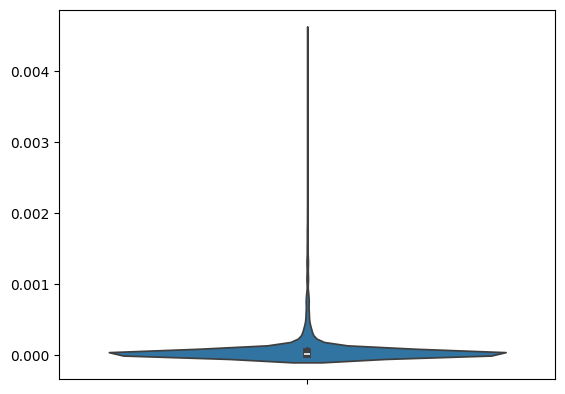

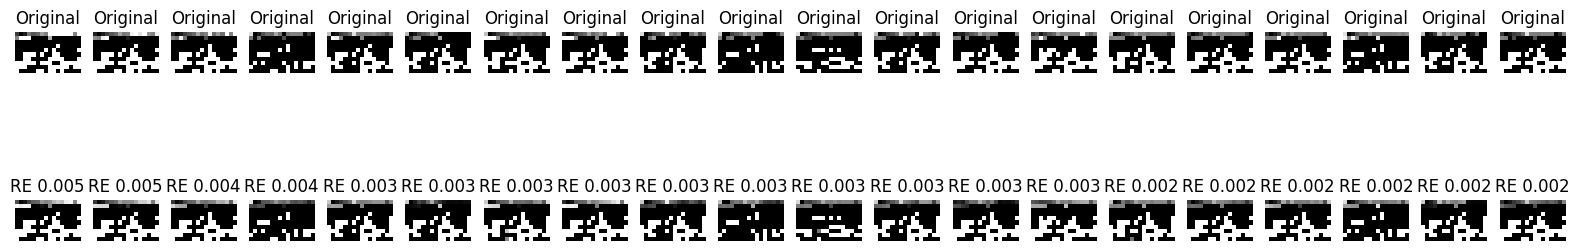

cross-val dataset: 192.168.1.169
raw dataset shape=(26365, 25)
['0000' '0005' '0010' '0017' '0023' '0033' '000B' '002B' 'FF01']


d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['0029'] will be ignored
  warnings.warn(
d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['0007', '000D', '0010', '0013', '0016', '0030', '0031', '0036', '0037', '003E', '003F', '0040', '0041', '0042', '0043', '0044', '0045', '0067', '0068', '0069', '006A', '006B', '0084', '0085', '0086', '0087', '0088', '0096', '0097', '0098', '0099', '009A', '00A0', '00A1', '00A2', '00A3', '00A4', '00A5', '0A0A', '1A1A', '2A2A', '3A3A', '4A4A', '5600', '5A5A', '6A6A', '7A7A', '8A8A', '9A9A', 'AAAA', 'BABA', 'C003', 'C004', 'C005', 'C008', 'C00D', 'C00E', 'C00F', 'C012', 'C025', 'C026', 'C029', 'C02A', 'C02D', 'C02E', 'C031', 'C032', 'CACA', 'CCAA', 'DADA', 'EAEA', 'FAFA'] will be ignored
  warnings.warn(
d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(e

(26365, 119)
824/824 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
Test reconstruction shape:
(26365,)
Number of false negatives for 1 sigma is 89 with threshold 0.0003659088298232819.
Number of true positives for 1 sigma is 26276 with threshold 0.0003659088298232819.
Number of false negatives for 2 sigma is 89 with threshold 0.0006438934478057171.
Number of true positives for 2 sigma is 26276 with threshold 0.0006438934478057171.
Number of false negatives for 3 sigma is 90 with threshold 0.0009218780657881523.
Number of true positives for 3 sigma is 26275 with threshold 0.0009218780657881523.
Reconstruction error for each sample: [0.03944671 0.02627015 0.04501535 ... 0.0344113  0.09519474 0.03402624]
Average reconstruction error: 0.038257772172758414
Min reconstruction error: 3.7235788980634933e-06
Max reconstruction error: 0.5099762598058682
Worst reconstructed:


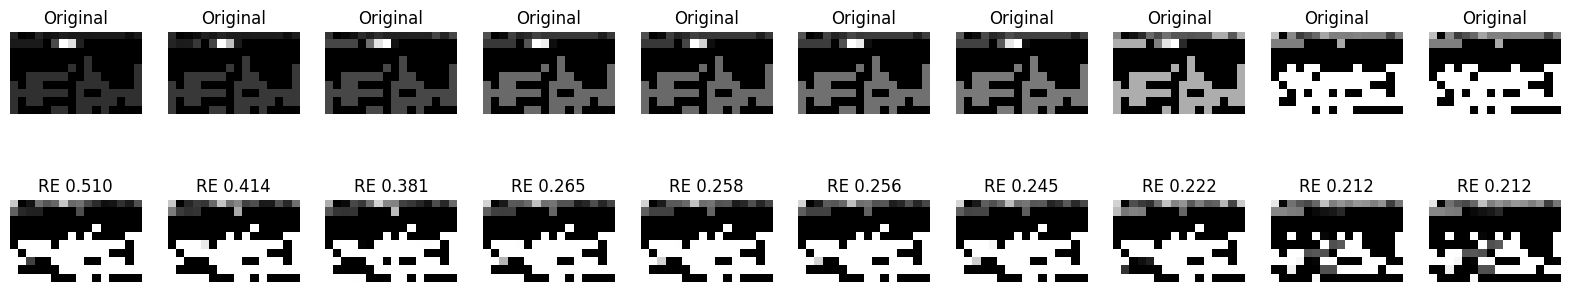

(26365, 25)
cross-val dataset: 192.168.1.172
raw dataset shape=(44492, 25)
['0000' '0005' '0010' '0017' '0023' '0033' '000B' '002B' 'FF01']


d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['0029'] will be ignored
  warnings.warn(
d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['0040', '0041', '0067', '006A', '006B', '0084', '008C', '008D', '0090', '0091', '0094', '0095', '00A2', '00A3', '00A8', '00A9', '00AA', '00AB', '00AC', '00AD', '00AE', '00AF', '00B2', '00B3', '00B6', '00B7', '0A0A', '1A1A', '2A2A', '3A3A', '4A4A', '5A5A', '6A6A', '7A7A', '8A8A', '9A9A', 'AAAA', 'BABA', 'C008', 'C012', 'C035', 'C036', 'C037', 'C038', 'C09C', 'C09D', 'C0A0', 'C0A1', 'C0AC', 'C0AD', 'C0AE', 'C0AF', 'CACA', 'CCAA', 'CCAB', 'CCAC', 'CCAD', 'CCAE', 'DADA', 'EAEA', 'FAFA'] will be ignored
  warnings.warn(
d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['0011', '0016', '0029', '002A', '0031', '0032', '0A0A', '1A1A', '2A2A', '3A3A', '44C

(44492, 119)
1391/1391 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
Test reconstruction shape:
(44492,)
Number of false negatives for 1 sigma is 39943 with threshold 0.0003659088298232819.
Number of true positives for 1 sigma is 4549 with threshold 0.0003659088298232819.
Number of false negatives for 2 sigma is 40949 with threshold 0.0006438934478057171.
Number of true positives for 2 sigma is 3543 with threshold 0.0006438934478057171.
Number of false negatives for 3 sigma is 41417 with threshold 0.0009218780657881523.
Number of true positives for 3 sigma is 3075 with threshold 0.0009218780657881523.
Reconstruction error for each sample: [2.33952191e-04 3.33603174e-05 2.62797070e-05 ... 8.83738945e-05
 8.67031096e-05 5.21273949e-05]
Average reconstruction error: 0.0015307060104459043
Min reconstruction error: 2.702726517071445e-06
Max reconstruction error: 0.2442433252207715
Worst reconstructed:


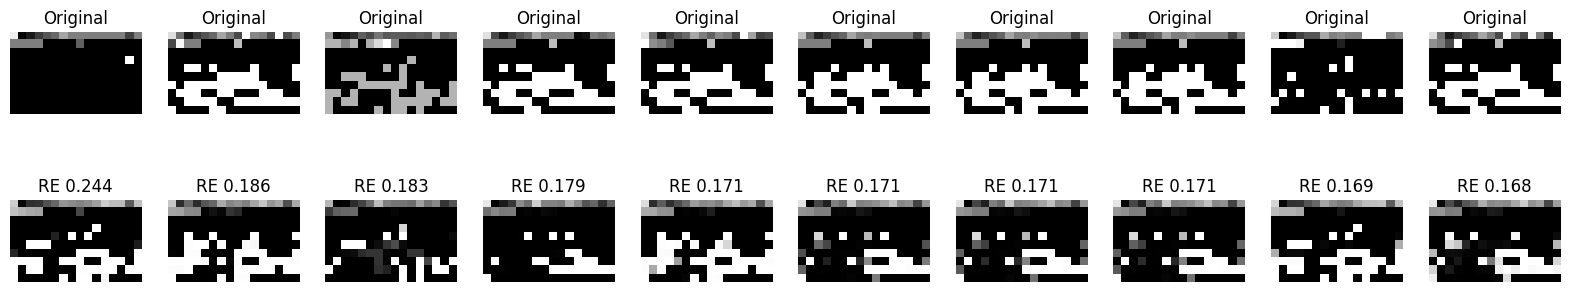

(44492, 25)
cross-val dataset: 192.168.1.174
raw dataset shape=(20091, 25)
['0000' '0005' '0010' '0017' '0023' '0033' '000B' '002B' 'FF01']


d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['0029'] will be ignored
  warnings.warn(
d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['0A0A', '1A1A', '2A2A', '3A3A', '4A4A', '5A5A', '6A6A', '7A7A', '8A8A', '9A9A', 'AAAA', 'BABA', 'C004', 'C005', 'C00E', 'C00F', 'C025', 'C026', 'C029', 'C02A', 'C02D', 'C02E', 'C031', 'C032', 'CACA', 'DADA', 'EAEA', 'FAFA'] will be ignored
  warnings.warn(
d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['0029', '002A', '0032', '0A0A', '1A1A', '2A2A', '3A3A', '44CD', '4A4A', '5A5A', '6A6A', '7A7A', '8A8A', '9A9A', 'AAAA', 'BABA', 'CACA', 'DADA', 'EAEA', 'FAFA'] will be ignored
  warnings.warn(
d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['0807'] will be ignored
  warnings.wa

(20091, 119)
628/628 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Test reconstruction shape:
(20091,)
Number of false negatives for 1 sigma is 18151 with threshold 0.0003659088298232819.
Number of true positives for 1 sigma is 1940 with threshold 0.0003659088298232819.
Number of false negatives for 2 sigma is 18521 with threshold 0.0006438934478057171.
Number of true positives for 2 sigma is 1570 with threshold 0.0006438934478057171.
Number of false negatives for 3 sigma is 18751 with threshold 0.0009218780657881523.
Number of true positives for 3 sigma is 1340 with threshold 0.0009218780657881523.
Reconstruction error for each sample: [8.44157264e-02 8.44995400e-02 5.48977933e-05 ... 6.44631310e-05
 1.62965065e-04 2.41288465e-05]
Average reconstruction error: 0.0014914227408311163
Min reconstruction error: 2.7471423432056836e-06
Max reconstruction error: 0.16445543471303076
Worst reconstructed:


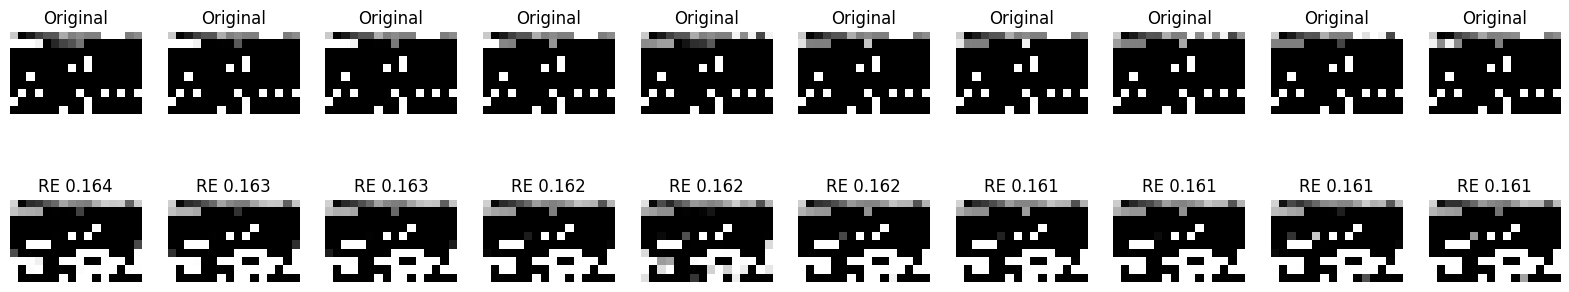

(20091, 25)
cross-val dataset: 192.168.1.181
raw dataset shape=(60253, 25)
['0000' '0005' '0010' '0017' '0023' '0033' '000B' '002B' 'FF01']


d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['0029', '3374'] will be ignored
  warnings.warn(
d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['0013', '0016', '0040', '0067', '006A', '006B', '00A2', '00A3', '0A0A', '1A1A', '2A2A', '3A3A', '4A4A', '5A5A', '6A6A', '7A7A', '8A8A', '9A9A', 'AAAA', 'BABA', 'C003', 'C004', 'C005', 'C008', 'C00D', 'C00E', 'C00F', 'C012', 'C025', 'C026', 'C029', 'C02A', 'C02D', 'C02E', 'C031', 'C032', 'CACA', 'CCAA', 'DADA', 'EAEA', 'FAFA'] will be ignored
  warnings.warn(
d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['000F', '0016', '0029', '002A', '0A0A', '1A1A', '2A2A', '3A3A', '44CD', '4A4A', '5A5A', '6A6A', '7A7A', '8A8A', '9A9A', 'AAAA', 'BABA', 'CACA', 'DADA', 'EAEA', 'FAFA', 'FF04'] will be ignored
  warnings.warn(
d:\GitHub\AutoFedProfile\.v

(60253, 119)
1883/1883 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
Test reconstruction shape:
(60253,)
Number of false negatives for 1 sigma is 50910 with threshold 0.0003659088298232819.
Number of true positives for 1 sigma is 9343 with threshold 0.0003659088298232819.
Number of false negatives for 2 sigma is 52011 with threshold 0.0006438934478057171.
Number of true positives for 2 sigma is 8242 with threshold 0.0006438934478057171.
Number of false negatives for 3 sigma is 52545 with threshold 0.0009218780657881523.
Number of true positives for 3 sigma is 7708 with threshold 0.0009218780657881523.
Reconstruction error for each sample: [4.64387725e-05 5.22788977e-04 1.17287010e-05 ... 1.03580750e-01
 9.35490901e-02 2.37915048e-05]
Average reconstruction error: 0.005791395081113095
Min reconstruction error: 2.4491910890776005e-06
Max reconstruction error: 0.2210342568455662
Worst reconstructed:


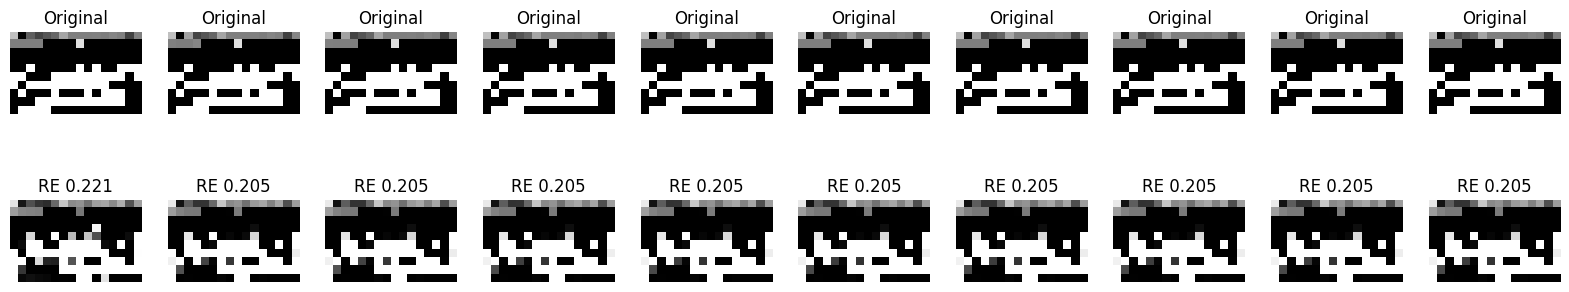

(60253, 25)
cross-val dataset: 192.168.1.185
raw dataset shape=(8579, 25)
['0000' '0005' '0010' '0017' '0023' '0033' '000B' '002B' 'FF01']


d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['0029'] will be ignored
  warnings.warn(
d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['0067', '006B', '0A0A', '1A1A', '2A2A', '3A3A', '4A4A', '5A5A', '6A6A', '7A7A', '8A8A', '9A9A', 'AAAA', 'BABA', 'C09C', 'C09D', 'C09E', 'C09F', 'C0AC', 'C0AD', 'CACA', 'DADA', 'EAEA', 'FAFA'] will be ignored
  warnings.warn(
d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['0016', '0029', '002A', '0A0A', '1A1A', '2A2A', '3A3A', '44CD', '4A4A', '5A5A', '6A6A', '7A7A', '8A8A', '9A9A', 'AAAA', 'BABA', 'CACA', 'DADA', 'EAEA', 'FAFA'] will be ignored
  warnings.warn(
d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['0807', '0808', '0809', '080A', '080B', '081A', '081B', '081C'] will 

(8579, 119)
269/269 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Test reconstruction shape:
(8579,)
Number of false negatives for 1 sigma is 2737 with threshold 0.0003659088298232819.
Number of true positives for 1 sigma is 5842 with threshold 0.0003659088298232819.
Number of false negatives for 2 sigma is 2952 with threshold 0.0006438934478057171.
Number of true positives for 2 sigma is 5627 with threshold 0.0006438934478057171.
Number of false negatives for 3 sigma is 3143 with threshold 0.0009218780657881523.
Number of true positives for 3 sigma is 5436 with threshold 0.0009218780657881523.
Reconstruction error for each sample: [8.56728683e-04 1.62689900e-05 4.33633832e-05 ... 1.68400344e-02
 1.85044115e-05 1.72856583e-02]
Average reconstruction error: 0.01265567285905414
Min reconstruction error: 3.883212130040966e-06
Max reconstruction error: 0.20758844387738537
Worst reconstructed:


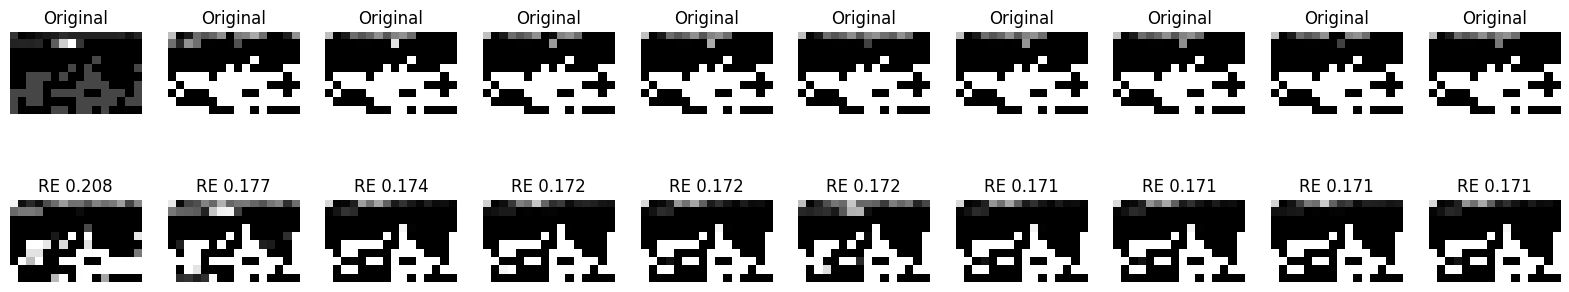

(8579, 25)
cross-val dataset: 192.168.1.197
raw dataset shape=(227962, 25)


d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['0029'] will be ignored
  warnings.warn(


['0000' '0005' '0010' '0017' '0023' '0033' '000B' '002B' 'FF01']


d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['0A0A', '1A1A', '2A2A', '3A3A', '4A4A', '5600', '5A5A', '6A6A', '7A7A', '8A8A', '9A9A', 'AAAA', 'BABA', 'C008', 'C012', 'CACA', 'DADA', 'EAEA', 'FAFA'] will be ignored
  warnings.warn(
d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['0014', '0029', '0A0A', '1A1A', '2A2A', '3A3A', '44CD', '4A4A', '5A5A', '6A6A', '7A7A', '8A8A', '9A9A', 'AAAA', 'BABA', 'CACA', 'DADA', 'EAEA', 'FAFA'] will be ignored
  warnings.warn(
d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['apns-pack-v1', 'apns-security-v3', 'dot', 'grpc-exp', 'http/1.0'] will be ignored
  warnings.warn(
d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['0301', '0302', '0A0A', '1A1A', '2A2A', '3A3A', '4A4A', '5

(227962, 119)
7124/7124 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step
Test reconstruction shape:
(227962,)
Number of false negatives for 1 sigma is 28476 with threshold 0.0003659088298232819.
Number of true positives for 1 sigma is 199486 with threshold 0.0003659088298232819.
Number of false negatives for 2 sigma is 31705 with threshold 0.0006438934478057171.
Number of true positives for 2 sigma is 196257 with threshold 0.0006438934478057171.
Number of false negatives for 3 sigma is 32864 with threshold 0.0009218780657881523.
Number of true positives for 3 sigma is 195098 with threshold 0.0009218780657881523.
Reconstruction error for each sample: [0.00968249 0.02674977 0.02017111 ... 0.04065479 0.00017541 0.01448519]
Average reconstruction error: 0.055217267654169115
Min reconstruction error: 2.6814821764357843e-06
Max reconstruction error: 1.8891101081065065
Worst reconstructed:


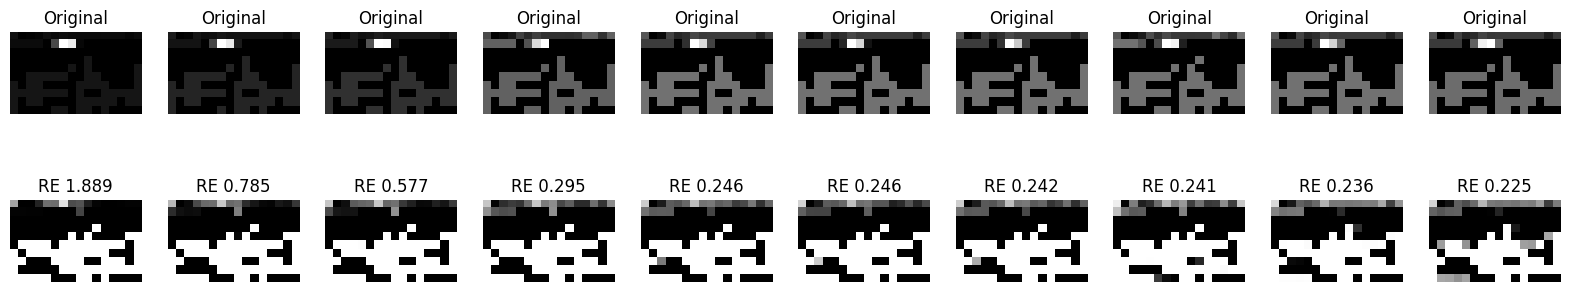

(227962, 25)

🌀 Fold 2/10
train shape=(41760, 157)
test shape=(4640, 157)
Epoch 1/100
1305/1305 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.1267 - val_loss: 0.0891
Epoch 2/100
1305/1305 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.0869 - val_loss: 0.0856
Epoch 3/100
1305/1305 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0848 - val_loss: 0.0844
Epoch 4/100
1305/1305 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0840 - val_loss: 0.0839
Epoch 5/100
1305/1305 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0837 - val_loss: 0.0836
Epoch 6/100
1305/1305 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.0835 - val_loss: 0.0836
Epoch 7/100
1305/1305 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.0833 - val_loss: 0.0833
Epoch 8/100
1305/1305 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.0832 - val_loss: 0.0837
Epoch 9/100
1305/1305 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.0831 - val_loss: 0.0831
Epoch 10/100
1305/1305 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.0831 - val_loss: 0.0831
Epoch 11/100
1305/1305 ━━━━━━━━━━━━

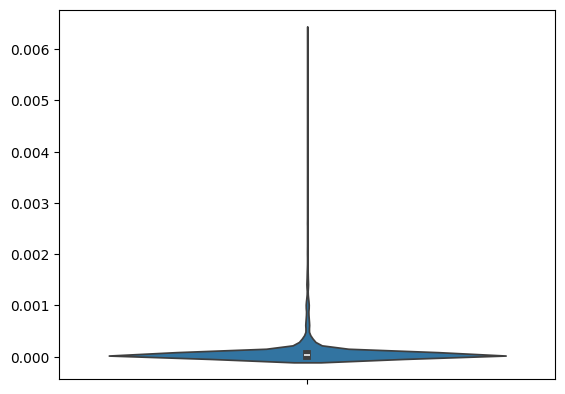

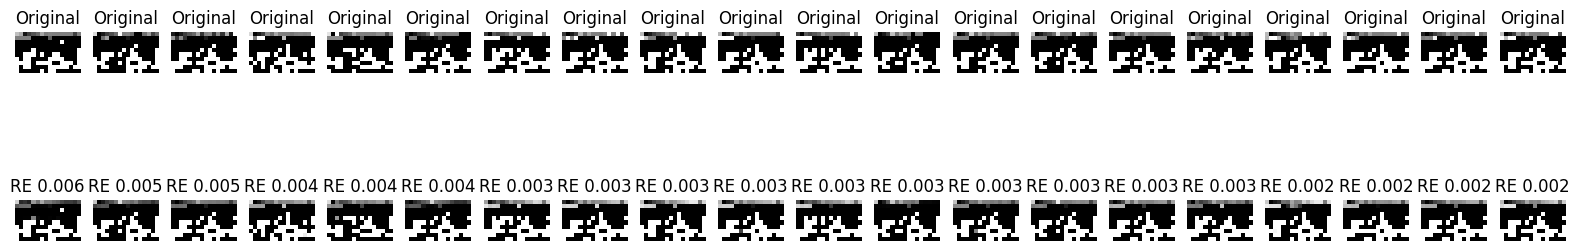

cross-val dataset: 192.168.1.169
raw dataset shape=(26365, 25)
['0000' '0005' '0010' '0017' '0023' '0033' '000B' '002B' 'FF01']


d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['0029'] will be ignored
  warnings.warn(
d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['0007', '000D', '0010', '0013', '0016', '0030', '0031', '0036', '0037', '003E', '003F', '0040', '0041', '0042', '0043', '0044', '0045', '0067', '0068', '0069', '006A', '006B', '0084', '0085', '0086', '0087', '0088', '0096', '0097', '0098', '0099', '009A', '00A0', '00A1', '00A2', '00A3', '00A4', '00A5', '0A0A', '1A1A', '2A2A', '3A3A', '4A4A', '5600', '5A5A', '6A6A', '7A7A', '8A8A', '9A9A', 'AAAA', 'BABA', 'C003', 'C004', 'C005', 'C008', 'C00D', 'C00E', 'C00F', 'C012', 'C025', 'C026', 'C029', 'C02A', 'C02D', 'C02E', 'C031', 'C032', 'CACA', 'CCAA', 'DADA', 'EAEA', 'FAFA'] will be ignored
  warnings.warn(
d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(e

(26365, 119)
824/824 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
Test reconstruction shape:
(26365,)
Number of false negatives for 1 sigma is 89 with threshold 0.00041160269170419664.
Number of true positives for 1 sigma is 26276 with threshold 0.00041160269170419664.
Number of false negatives for 2 sigma is 89 with threshold 0.0007212812565918331.
Number of true positives for 2 sigma is 26276 with threshold 0.0007212812565918331.
Number of false negatives for 3 sigma is 90 with threshold 0.0010309598214794694.
Number of true positives for 3 sigma is 26275 with threshold 0.0010309598214794694.
Reconstruction error for each sample: [0.03045837 0.03497875 0.02915355 ... 0.03308506 0.0893365  0.02216954]
Average reconstruction error: 0.03845171438108513
Min reconstruction error: 6.957003209992517e-06
Max reconstruction error: 0.4147492432436532
Worst reconstructed:


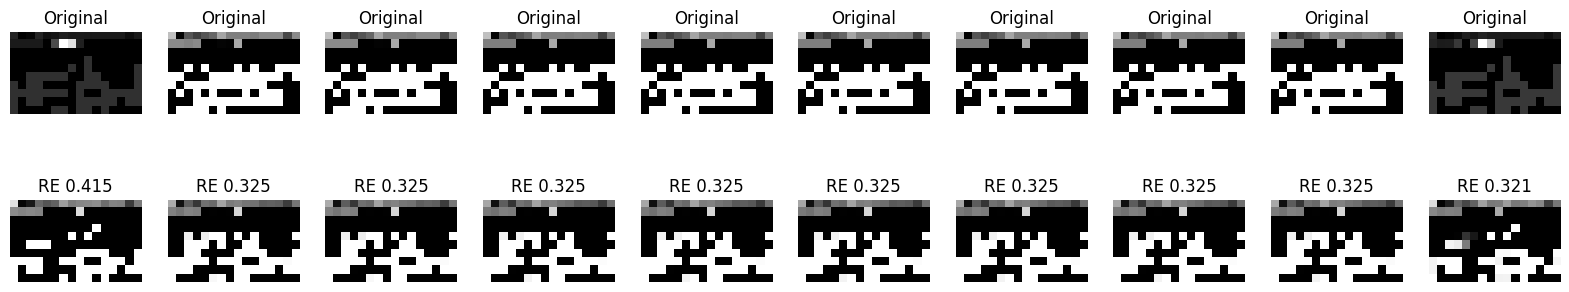

(26365, 25)
cross-val dataset: 192.168.1.172
raw dataset shape=(44492, 25)
['0000' '0005' '0010' '0017' '0023' '0033' '000B' '002B' 'FF01']


d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['0029'] will be ignored
  warnings.warn(
d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['0040', '0041', '0067', '006A', '006B', '0084', '008C', '008D', '0090', '0091', '0094', '0095', '00A2', '00A3', '00A8', '00A9', '00AA', '00AB', '00AC', '00AD', '00AE', '00AF', '00B2', '00B3', '00B6', '00B7', '0A0A', '1A1A', '2A2A', '3A3A', '4A4A', '5A5A', '6A6A', '7A7A', '8A8A', '9A9A', 'AAAA', 'BABA', 'C008', 'C012', 'C035', 'C036', 'C037', 'C038', 'C09C', 'C09D', 'C0A0', 'C0A1', 'C0AC', 'C0AD', 'C0AE', 'C0AF', 'CACA', 'CCAA', 'CCAB', 'CCAC', 'CCAD', 'CCAE', 'DADA', 'EAEA', 'FAFA'] will be ignored
  warnings.warn(
d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['0011', '0016', '0029', '002A', '0031', '0032', '0A0A', '1A1A', '2A2A', '3A3A', '44C

(44492, 119)
1391/1391 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
Test reconstruction shape:
(44492,)
Number of false negatives for 1 sigma is 39829 with threshold 0.00041160269170419664.
Number of true positives for 1 sigma is 4663 with threshold 0.00041160269170419664.
Number of false negatives for 2 sigma is 40779 with threshold 0.0007212812565918331.
Number of true positives for 2 sigma is 3713 with threshold 0.0007212812565918331.
Number of false negatives for 3 sigma is 41271 with threshold 0.0010309598214794694.
Number of true positives for 3 sigma is 3221 with threshold 0.0010309598214794694.
Reconstruction error for each sample: [2.33491594e-04 9.12468882e-05 1.37171910e-05 ... 1.59694474e-04
 1.28907550e-04 7.18940407e-05]
Average reconstruction error: 0.001576957909030626
Min reconstruction error: 4.2266234831740094e-06
Max reconstruction error: 0.2870908458894881
Worst reconstructed:


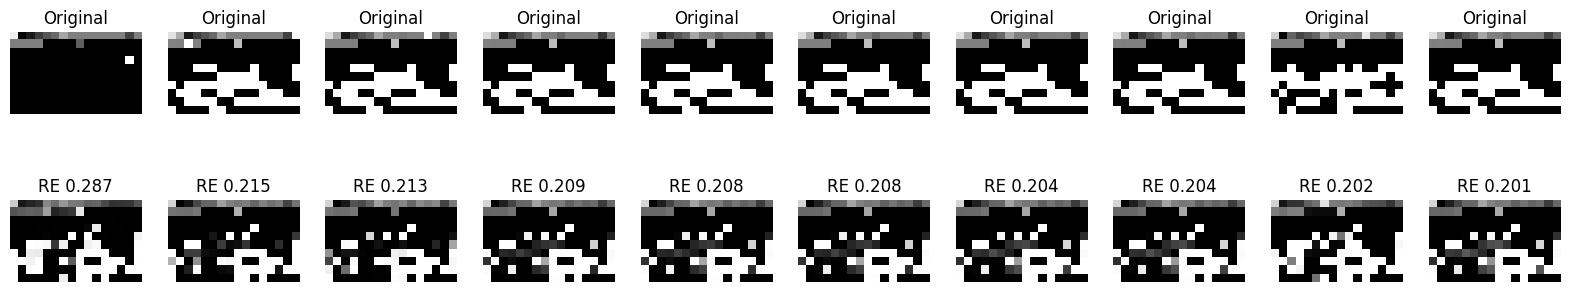

(44492, 25)
cross-val dataset: 192.168.1.174
raw dataset shape=(20091, 25)
['0000' '0005' '0010' '0017' '0023' '0033' '000B' '002B' 'FF01']


d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['0029'] will be ignored
  warnings.warn(
d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['0A0A', '1A1A', '2A2A', '3A3A', '4A4A', '5A5A', '6A6A', '7A7A', '8A8A', '9A9A', 'AAAA', 'BABA', 'C004', 'C005', 'C00E', 'C00F', 'C025', 'C026', 'C029', 'C02A', 'C02D', 'C02E', 'C031', 'C032', 'CACA', 'DADA', 'EAEA', 'FAFA'] will be ignored
  warnings.warn(
d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['0029', '002A', '0032', '0A0A', '1A1A', '2A2A', '3A3A', '44CD', '4A4A', '5A5A', '6A6A', '7A7A', '8A8A', '9A9A', 'AAAA', 'BABA', 'CACA', 'DADA', 'EAEA', 'FAFA'] will be ignored
  warnings.warn(
d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['0807'] will be ignored
  warnings.wa

(20091, 119)
628/628 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Test reconstruction shape:
(20091,)
Number of false negatives for 1 sigma is 18251 with threshold 0.00041160269170419664.
Number of true positives for 1 sigma is 1840 with threshold 0.00041160269170419664.
Number of false negatives for 2 sigma is 18628 with threshold 0.0007212812565918331.
Number of true positives for 2 sigma is 1463 with threshold 0.0007212812565918331.
Number of false negatives for 3 sigma is 18872 with threshold 0.0010309598214794694.
Number of true positives for 3 sigma is 1219 with threshold 0.0010309598214794694.
Reconstruction error for each sample: [8.99136327e-02 9.02611023e-02 2.43632150e-05 ... 1.57719778e-04
 2.50127956e-04 5.53958680e-05]
Average reconstruction error: 0.0016002730149140183
Min reconstruction error: 4.689737260189888e-06
Max reconstruction error: 0.17456210661995167
Worst reconstructed:


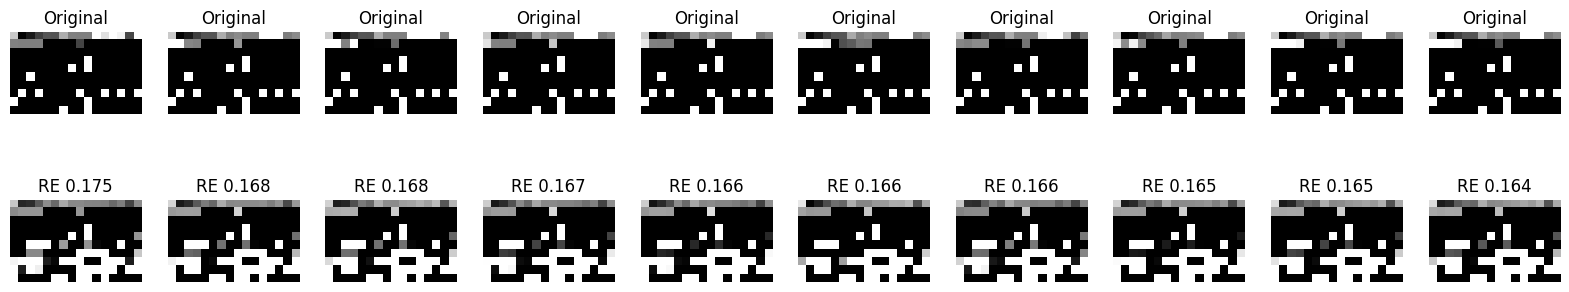

(20091, 25)
cross-val dataset: 192.168.1.181
raw dataset shape=(60253, 25)
['0000' '0005' '0010' '0017' '0023' '0033' '000B' '002B' 'FF01']


d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['0029', '3374'] will be ignored
  warnings.warn(
d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['0013', '0016', '0040', '0067', '006A', '006B', '00A2', '00A3', '0A0A', '1A1A', '2A2A', '3A3A', '4A4A', '5A5A', '6A6A', '7A7A', '8A8A', '9A9A', 'AAAA', 'BABA', 'C003', 'C004', 'C005', 'C008', 'C00D', 'C00E', 'C00F', 'C012', 'C025', 'C026', 'C029', 'C02A', 'C02D', 'C02E', 'C031', 'C032', 'CACA', 'CCAA', 'DADA', 'EAEA', 'FAFA'] will be ignored
  warnings.warn(
d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['000F', '0016', '0029', '002A', '0A0A', '1A1A', '2A2A', '3A3A', '44CD', '4A4A', '5A5A', '6A6A', '7A7A', '8A8A', '9A9A', 'AAAA', 'BABA', 'CACA', 'DADA', 'EAEA', 'FAFA', 'FF04'] will be ignored
  warnings.warn(
d:\GitHub\AutoFedProfile\.v

(60253, 119)
1883/1883 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
Test reconstruction shape:
(60253,)
Number of false negatives for 1 sigma is 50863 with threshold 0.00041160269170419664.
Number of true positives for 1 sigma is 9390 with threshold 0.00041160269170419664.
Number of false negatives for 2 sigma is 52157 with threshold 0.0007212812565918331.
Number of true positives for 2 sigma is 8096 with threshold 0.0007212812565918331.
Number of false negatives for 3 sigma is 52812 with threshold 0.0010309598214794694.
Number of true positives for 3 sigma is 7441 with threshold 0.0010309598214794694.
Reconstruction error for each sample: [6.89895172e-05 6.60399162e-04 8.15290215e-06 ... 4.63257725e-02
 5.28349848e-02 5.95171313e-05]
Average reconstruction error: 0.0035724587864991338
Min reconstruction error: 4.594189564442538e-06
Max reconstruction error: 0.33831736348711733
Worst reconstructed:


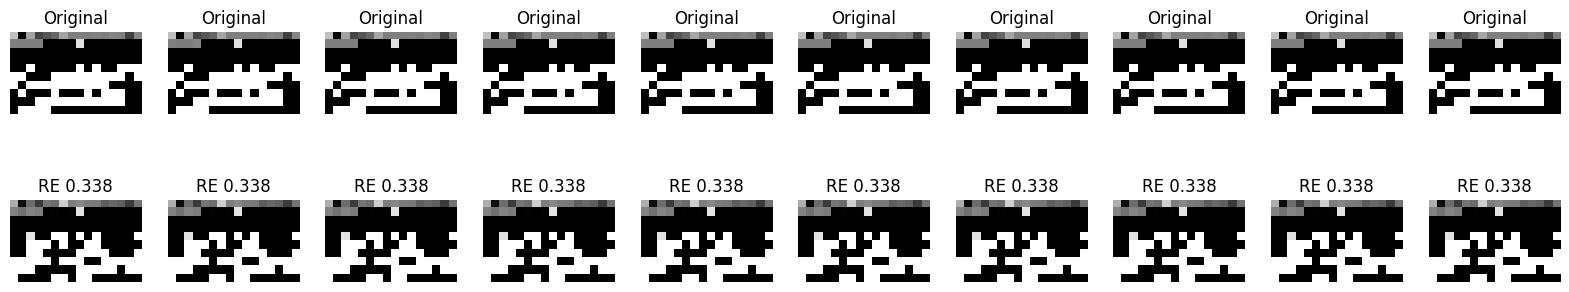

(60253, 25)
cross-val dataset: 192.168.1.185
raw dataset shape=(8579, 25)
['0000' '0005' '0010' '0017' '0023' '0033' '000B' '002B' 'FF01']


d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['0029'] will be ignored
  warnings.warn(
d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['0067', '006B', '0A0A', '1A1A', '2A2A', '3A3A', '4A4A', '5A5A', '6A6A', '7A7A', '8A8A', '9A9A', 'AAAA', 'BABA', 'C09C', 'C09D', 'C09E', 'C09F', 'C0AC', 'C0AD', 'CACA', 'DADA', 'EAEA', 'FAFA'] will be ignored
  warnings.warn(
d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['0016', '0029', '002A', '0A0A', '1A1A', '2A2A', '3A3A', '44CD', '4A4A', '5A5A', '6A6A', '7A7A', '8A8A', '9A9A', 'AAAA', 'BABA', 'CACA', 'DADA', 'EAEA', 'FAFA'] will be ignored
  warnings.warn(
d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['0807', '0808', '0809', '080A', '080B', '081A', '081B', '081C'] will 

(8579, 119)
269/269 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Test reconstruction shape:
(8579,)
Number of false negatives for 1 sigma is 2724 with threshold 0.00041160269170419664.
Number of true positives for 1 sigma is 5855 with threshold 0.00041160269170419664.
Number of false negatives for 2 sigma is 2782 with threshold 0.0007212812565918331.
Number of true positives for 2 sigma is 5797 with threshold 0.0007212812565918331.
Number of false negatives for 3 sigma is 2825 with threshold 0.0010309598214794694.
Number of true positives for 3 sigma is 5754 with threshold 0.0010309598214794694.
Reconstruction error for each sample: [1.97015037e-03 1.25572768e-05 2.59436414e-05 ... 8.44644752e-03
 5.40103249e-05 8.70646513e-03]
Average reconstruction error: 0.027716726950569696
Min reconstruction error: 5.546301358225313e-06
Max reconstruction error: 0.2166088642865022
Worst reconstructed:


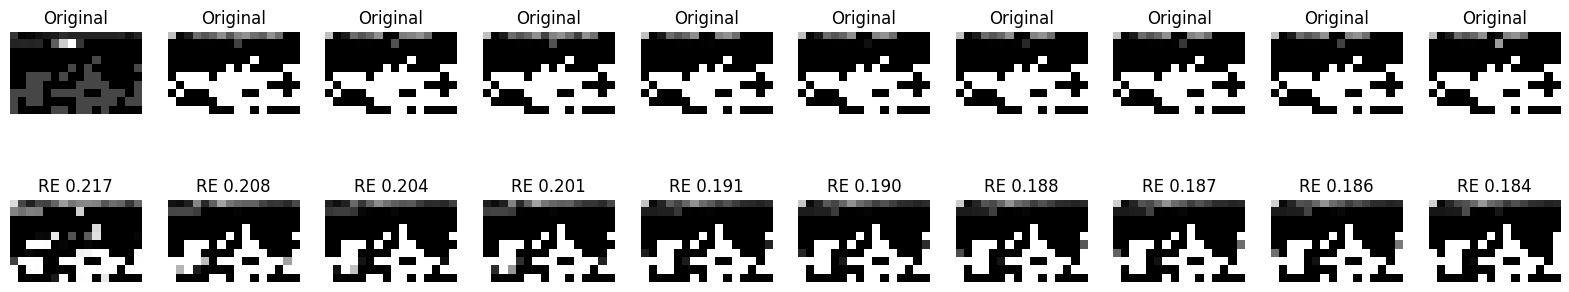

(8579, 25)
cross-val dataset: 192.168.1.197
raw dataset shape=(227962, 25)


d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['0029'] will be ignored
  warnings.warn(


['0000' '0005' '0010' '0017' '0023' '0033' '000B' '002B' 'FF01']


d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['0A0A', '1A1A', '2A2A', '3A3A', '4A4A', '5600', '5A5A', '6A6A', '7A7A', '8A8A', '9A9A', 'AAAA', 'BABA', 'C008', 'C012', 'CACA', 'DADA', 'EAEA', 'FAFA'] will be ignored
  warnings.warn(
d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['0014', '0029', '0A0A', '1A1A', '2A2A', '3A3A', '44CD', '4A4A', '5A5A', '6A6A', '7A7A', '8A8A', '9A9A', 'AAAA', 'BABA', 'CACA', 'DADA', 'EAEA', 'FAFA'] will be ignored
  warnings.warn(
d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['apns-pack-v1', 'apns-security-v3', 'dot', 'grpc-exp', 'http/1.0'] will be ignored
  warnings.warn(
d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['0301', '0302', '0A0A', '1A1A', '2A2A', '3A3A', '4A4A', '5

(227962, 119)
7124/7124 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step
Test reconstruction shape:
(227962,)
Number of false negatives for 1 sigma is 27864 with threshold 0.00041160269170419664.
Number of true positives for 1 sigma is 200098 with threshold 0.00041160269170419664.
Number of false negatives for 2 sigma is 29325 with threshold 0.0007212812565918331.
Number of true positives for 2 sigma is 198637 with threshold 0.0007212812565918331.
Number of false negatives for 3 sigma is 30499 with threshold 0.0010309598214794694.
Number of true positives for 3 sigma is 197463 with threshold 0.0010309598214794694.
Reconstruction error for each sample: [0.01295469 0.0372015  0.01710009 ... 0.03327511 0.00019583 0.0082827 ]
Average reconstruction error: 0.054382952672976936
Min reconstruction error: 5.308038558735102e-06
Max reconstruction error: 1.8629183562813025
Worst reconstructed:


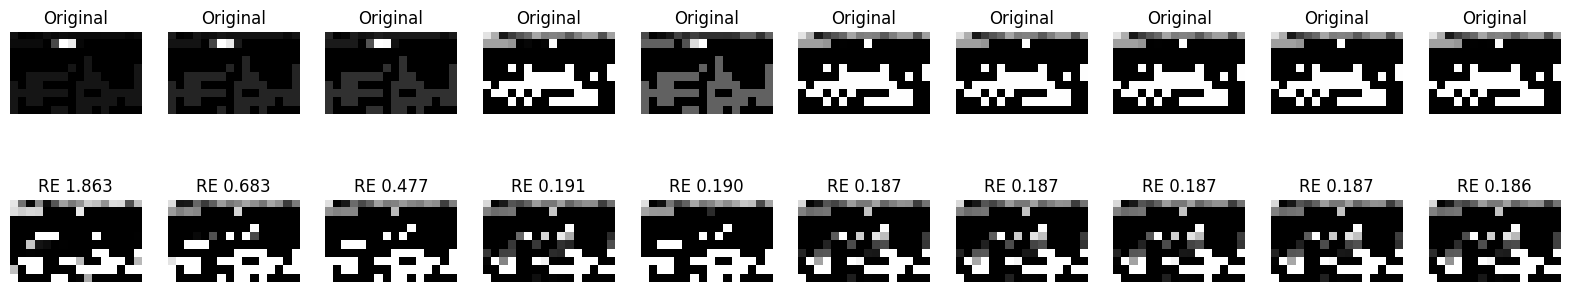

(227962, 25)

🌀 Fold 3/10
train shape=(41760, 157)
test shape=(4640, 157)
Epoch 1/100
1305/1305 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.1160 - val_loss: 0.0873
Epoch 2/100
1305/1305 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.0859 - val_loss: 0.0853
Epoch 3/100
1305/1305 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.0845 - val_loss: 0.0842
Epoch 4/100
1305/1305 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.0838 - val_loss: 0.0836
Epoch 5/100
1305/1305 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.0835 - val_loss: 0.0833
Epoch 6/100
1305/1305 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.0832 - val_loss: 0.0832
Epoch 7/100
1305/1305 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.0831 - val_loss: 0.0830
Epoch 8/100
1305/1305 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.0830 - val_loss: 0.0830
Epoch 9/100
1305/1305 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.0832 - val_loss: 0.0831
Epoch 10/100
1305/1305 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.0829 - val_loss: 0.0829
Epoch 11/100
1305/1305 ━━━━━━━━━━━━

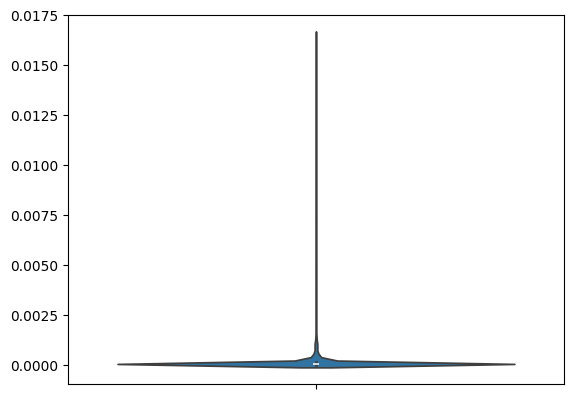

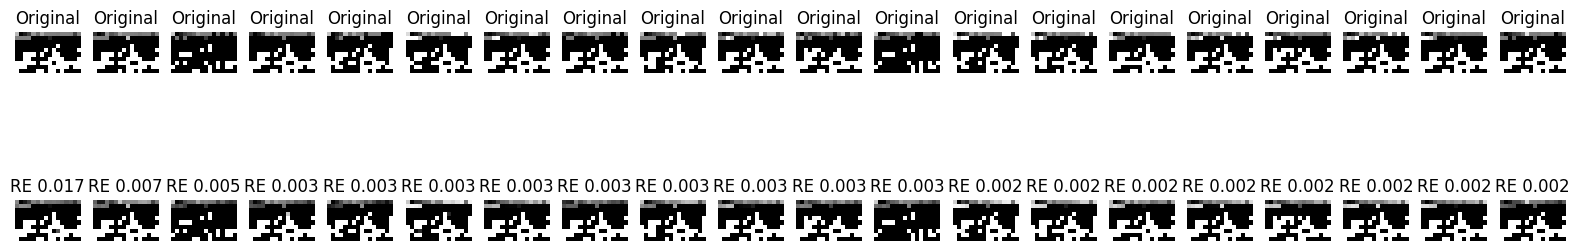

cross-val dataset: 192.168.1.169
raw dataset shape=(26365, 25)
['0000' '0005' '0010' '0017' '0023' '0033' '000B' '002B' 'FF01']


d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['0029'] will be ignored
  warnings.warn(
d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['0007', '000D', '0010', '0013', '0016', '0030', '0031', '0036', '0037', '003E', '003F', '0040', '0041', '0042', '0043', '0044', '0045', '0067', '0068', '0069', '006A', '006B', '0084', '0085', '0086', '0087', '0088', '0096', '0097', '0098', '0099', '009A', '00A0', '00A1', '00A2', '00A3', '00A4', '00A5', '0A0A', '1A1A', '2A2A', '3A3A', '4A4A', '5600', '5A5A', '6A6A', '7A7A', '8A8A', '9A9A', 'AAAA', 'BABA', 'C003', 'C004', 'C005', 'C008', 'C00D', 'C00E', 'C00F', 'C012', 'C025', 'C026', 'C029', 'C02A', 'C02D', 'C02E', 'C031', 'C032', 'CACA', 'CCAA', 'DADA', 'EAEA', 'FAFA'] will be ignored
  warnings.warn(
d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(e

(26365, 119)
824/824 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
Test reconstruction shape:
(26365,)
Number of false negatives for 1 sigma is 89 with threshold 0.00045966176948779904.
Number of true positives for 1 sigma is 26276 with threshold 0.00045966176948779904.
Number of false negatives for 2 sigma is 90 with threshold 0.0008242904038306778.
Number of true positives for 2 sigma is 26275 with threshold 0.0008242904038306778.
Number of false negatives for 3 sigma is 90 with threshold 0.0011889190381735566.
Number of true positives for 3 sigma is 26275 with threshold 0.0011889190381735566.
Reconstruction error for each sample: [0.02994209 0.03702934 0.02959937 ... 0.03252089 0.08943124 0.02007148]
Average reconstruction error: 0.03284582285782163
Min reconstruction error: 1.269343759768813e-05
Max reconstruction error: 0.4856659597815846
Worst reconstructed:


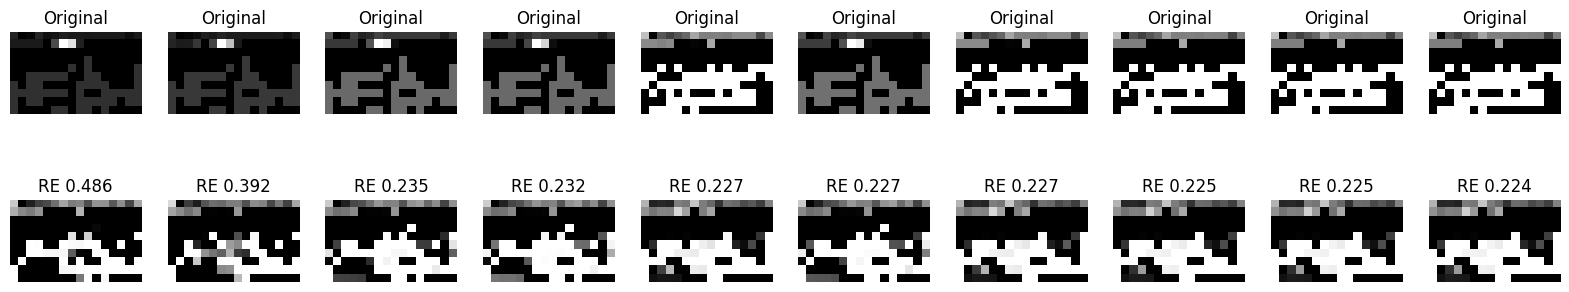

(26365, 25)
cross-val dataset: 192.168.1.172
raw dataset shape=(44492, 25)
['0000' '0005' '0010' '0017' '0023' '0033' '000B' '002B' 'FF01']


d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['0029'] will be ignored
  warnings.warn(
d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['0040', '0041', '0067', '006A', '006B', '0084', '008C', '008D', '0090', '0091', '0094', '0095', '00A2', '00A3', '00A8', '00A9', '00AA', '00AB', '00AC', '00AD', '00AE', '00AF', '00B2', '00B3', '00B6', '00B7', '0A0A', '1A1A', '2A2A', '3A3A', '4A4A', '5A5A', '6A6A', '7A7A', '8A8A', '9A9A', 'AAAA', 'BABA', 'C008', 'C012', 'C035', 'C036', 'C037', 'C038', 'C09C', 'C09D', 'C0A0', 'C0A1', 'C0AC', 'C0AD', 'C0AE', 'C0AF', 'CACA', 'CCAA', 'CCAB', 'CCAC', 'CCAD', 'CCAE', 'DADA', 'EAEA', 'FAFA'] will be ignored
  warnings.warn(
d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['0011', '0016', '0029', '002A', '0031', '0032', '0A0A', '1A1A', '2A2A', '3A3A', '44C

(44492, 119)
1391/1391 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
Test reconstruction shape:
(44492,)
Number of false negatives for 1 sigma is 40213 with threshold 0.00045966176948779904.
Number of true positives for 1 sigma is 4279 with threshold 0.00045966176948779904.
Number of false negatives for 2 sigma is 41101 with threshold 0.0008242904038306778.
Number of true positives for 2 sigma is 3391 with threshold 0.0008242904038306778.
Number of false negatives for 3 sigma is 41739 with threshold 0.0011889190381735566.
Number of true positives for 3 sigma is 2753 with threshold 0.0011889190381735566.
Reconstruction error for each sample: [2.09529139e-04 7.62804930e-05 1.44071249e-05 ... 6.74697014e-05
 9.38686451e-05 6.06477597e-05]
Average reconstruction error: 0.0012662263616273336
Min reconstruction error: 4.514950088146233e-06
Max reconstruction error: 0.2983402259317733
Worst reconstructed:


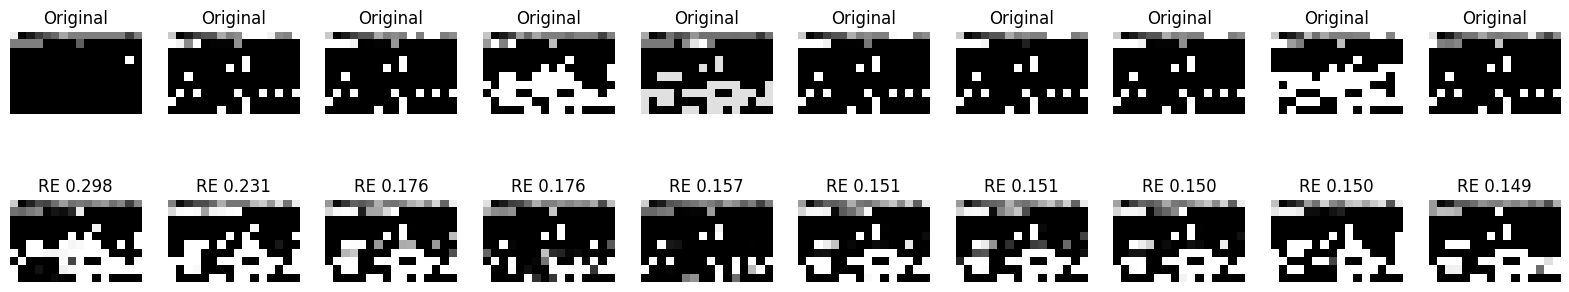

(44492, 25)
cross-val dataset: 192.168.1.174
raw dataset shape=(20091, 25)
['0000' '0005' '0010' '0017' '0023' '0033' '000B' '002B' 'FF01']


d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['0029'] will be ignored
  warnings.warn(
d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['0A0A', '1A1A', '2A2A', '3A3A', '4A4A', '5A5A', '6A6A', '7A7A', '8A8A', '9A9A', 'AAAA', 'BABA', 'C004', 'C005', 'C00E', 'C00F', 'C025', 'C026', 'C029', 'C02A', 'C02D', 'C02E', 'C031', 'C032', 'CACA', 'DADA', 'EAEA', 'FAFA'] will be ignored
  warnings.warn(
d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['0029', '002A', '0032', '0A0A', '1A1A', '2A2A', '3A3A', '44CD', '4A4A', '5A5A', '6A6A', '7A7A', '8A8A', '9A9A', 'AAAA', 'BABA', 'CACA', 'DADA', 'EAEA', 'FAFA'] will be ignored
  warnings.warn(
d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['0807'] will be ignored
  warnings.wa

(20091, 119)
628/628 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Test reconstruction shape:
(20091,)
Number of false negatives for 1 sigma is 18520 with threshold 0.00045966176948779904.
Number of true positives for 1 sigma is 1571 with threshold 0.00045966176948779904.
Number of false negatives for 2 sigma is 18836 with threshold 0.0008242904038306778.
Number of true positives for 2 sigma is 1255 with threshold 0.0008242904038306778.
Number of false negatives for 3 sigma is 19084 with threshold 0.0011889190381735566.
Number of true positives for 3 sigma is 1007 with threshold 0.0011889190381735566.
Reconstruction error for each sample: [5.49456077e-02 5.55643925e-02 4.39378684e-05 ... 5.32550537e-05
 1.25440348e-04 2.05788340e-05]
Average reconstruction error: 0.0008514803086119535
Min reconstruction error: 4.605755603868599e-06
Max reconstruction error: 0.22774370807392733
Worst reconstructed:


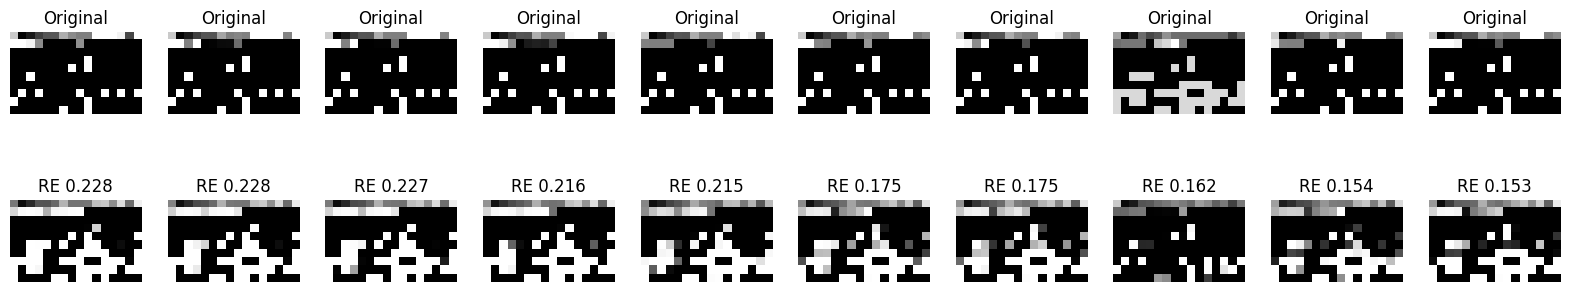

(20091, 25)
cross-val dataset: 192.168.1.181
raw dataset shape=(60253, 25)
['0000' '0005' '0010' '0017' '0023' '0033' '000B' '002B' 'FF01']


d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['0029', '3374'] will be ignored
  warnings.warn(
d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['0013', '0016', '0040', '0067', '006A', '006B', '00A2', '00A3', '0A0A', '1A1A', '2A2A', '3A3A', '4A4A', '5A5A', '6A6A', '7A7A', '8A8A', '9A9A', 'AAAA', 'BABA', 'C003', 'C004', 'C005', 'C008', 'C00D', 'C00E', 'C00F', 'C012', 'C025', 'C026', 'C029', 'C02A', 'C02D', 'C02E', 'C031', 'C032', 'CACA', 'CCAA', 'DADA', 'EAEA', 'FAFA'] will be ignored
  warnings.warn(
d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['000F', '0016', '0029', '002A', '0A0A', '1A1A', '2A2A', '3A3A', '44CD', '4A4A', '5A5A', '6A6A', '7A7A', '8A8A', '9A9A', 'AAAA', 'BABA', 'CACA', 'DADA', 'EAEA', 'FAFA', 'FF04'] will be ignored
  warnings.warn(
d:\GitHub\AutoFedProfile\.v

(60253, 119)
1883/1883 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
Test reconstruction shape:
(60253,)
Number of false negatives for 1 sigma is 51680 with threshold 0.00045966176948779904.
Number of true positives for 1 sigma is 8573 with threshold 0.00045966176948779904.
Number of false negatives for 2 sigma is 52697 with threshold 0.0008242904038306778.
Number of true positives for 2 sigma is 7556 with threshold 0.0008242904038306778.
Number of false negatives for 3 sigma is 53398 with threshold 0.0011889190381735566.
Number of true positives for 3 sigma is 6855 with threshold 0.0011889190381735566.
Reconstruction error for each sample: [8.97464475e-05 5.65708287e-04 1.13639852e-05 ... 4.34241552e-02
 2.10396052e-02 2.49618698e-05]
Average reconstruction error: 0.0024724641379289536
Min reconstruction error: 4.201428619297213e-06
Max reconstruction error: 0.2559527076272687
Worst reconstructed:


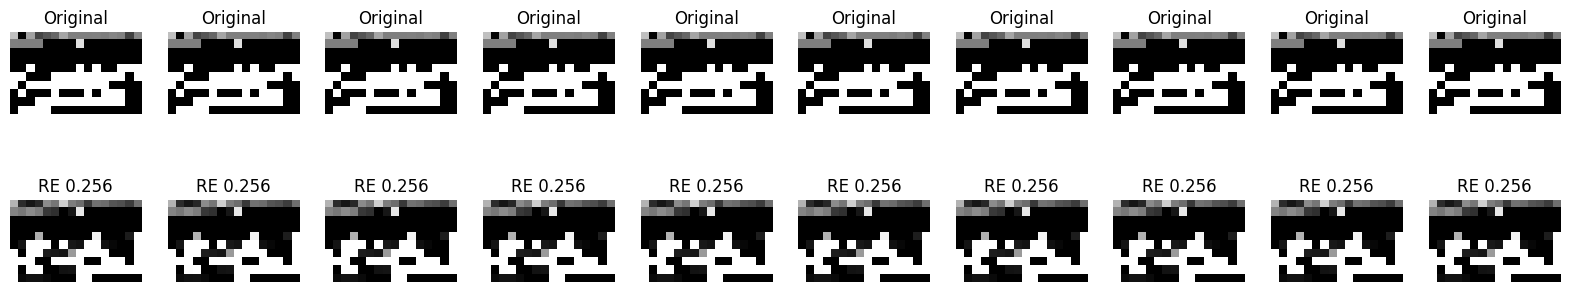

(60253, 25)
cross-val dataset: 192.168.1.185
raw dataset shape=(8579, 25)
['0000' '0005' '0010' '0017' '0023' '0033' '000B' '002B' 'FF01']


d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['0029'] will be ignored
  warnings.warn(
d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['0067', '006B', '0A0A', '1A1A', '2A2A', '3A3A', '4A4A', '5A5A', '6A6A', '7A7A', '8A8A', '9A9A', 'AAAA', 'BABA', 'C09C', 'C09D', 'C09E', 'C09F', 'C0AC', 'C0AD', 'CACA', 'DADA', 'EAEA', 'FAFA'] will be ignored
  warnings.warn(
d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['0016', '0029', '002A', '0A0A', '1A1A', '2A2A', '3A3A', '44CD', '4A4A', '5A5A', '6A6A', '7A7A', '8A8A', '9A9A', 'AAAA', 'BABA', 'CACA', 'DADA', 'EAEA', 'FAFA'] will be ignored
  warnings.warn(
d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['0807', '0808', '0809', '080A', '080B', '081A', '081B', '081C'] will 

(8579, 119)
269/269 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Test reconstruction shape:
(8579,)
Number of false negatives for 1 sigma is 2894 with threshold 0.00045966176948779904.
Number of true positives for 1 sigma is 5685 with threshold 0.00045966176948779904.
Number of false negatives for 2 sigma is 3080 with threshold 0.0008242904038306778.
Number of true positives for 2 sigma is 5499 with threshold 0.0008242904038306778.
Number of false negatives for 3 sigma is 3162 with threshold 0.0011889190381735566.
Number of true positives for 3 sigma is 5417 with threshold 0.0011889190381735566.
Reconstruction error for each sample: [1.32838649e-03 1.31992803e-05 2.38279508e-05 ... 1.15545556e-02
 1.90097582e-05 1.30111247e-02]
Average reconstruction error: 0.010114173454226478
Min reconstruction error: 4.559367149900516e-06
Max reconstruction error: 0.31684338501118753
Worst reconstructed:


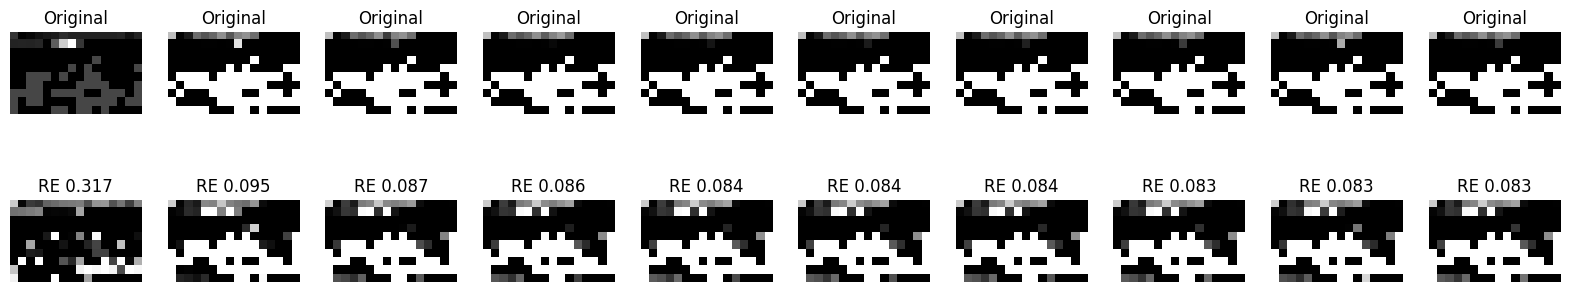

(8579, 25)
cross-val dataset: 192.168.1.197
raw dataset shape=(227962, 25)


d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['0029'] will be ignored
  warnings.warn(


['0000' '0005' '0010' '0017' '0023' '0033' '000B' '002B' 'FF01']


d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['0A0A', '1A1A', '2A2A', '3A3A', '4A4A', '5600', '5A5A', '6A6A', '7A7A', '8A8A', '9A9A', 'AAAA', 'BABA', 'C008', 'C012', 'CACA', 'DADA', 'EAEA', 'FAFA'] will be ignored
  warnings.warn(
d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['0014', '0029', '0A0A', '1A1A', '2A2A', '3A3A', '44CD', '4A4A', '5A5A', '6A6A', '7A7A', '8A8A', '9A9A', 'AAAA', 'BABA', 'CACA', 'DADA', 'EAEA', 'FAFA'] will be ignored
  warnings.warn(
d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['apns-pack-v1', 'apns-security-v3', 'dot', 'grpc-exp', 'http/1.0'] will be ignored
  warnings.warn(
d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['0301', '0302', '0A0A', '1A1A', '2A2A', '3A3A', '4A4A', '5

(227962, 119)
7124/7124 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step
Test reconstruction shape:
(227962,)
Number of false negatives for 1 sigma is 28038 with threshold 0.00045966176948779904.
Number of true positives for 1 sigma is 199924 with threshold 0.00045966176948779904.
Number of false negatives for 2 sigma is 30389 with threshold 0.0008242904038306778.
Number of true positives for 2 sigma is 197573 with threshold 0.0008242904038306778.
Number of false negatives for 3 sigma is 41537 with threshold 0.0011889190381735566.
Number of true positives for 3 sigma is 186425 with threshold 0.0011889190381735566.
Reconstruction error for each sample: [0.01298837 0.03775128 0.01901149 ... 0.03405219 0.00010804 0.01043983]
Average reconstruction error: 0.04913222266036004
Min reconstruction error: 7.4787106799109445e-06
Max reconstruction error: 1.84922535844375
Worst reconstructed:


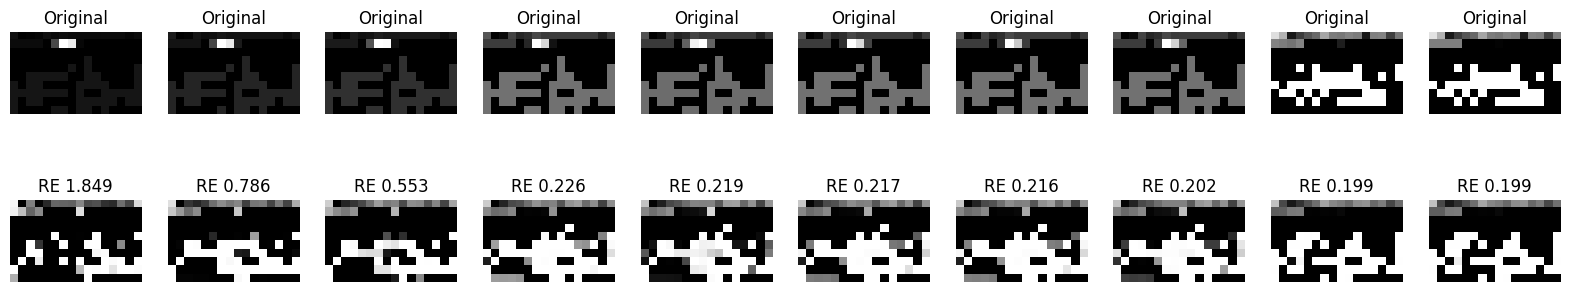

(227962, 25)

🌀 Fold 4/10
train shape=(41760, 157)
test shape=(4640, 157)
Epoch 1/100
1305/1305 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.1187 - val_loss: 0.0884
Epoch 2/100
1305/1305 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0869 - val_loss: 0.0857
Epoch 3/100
1305/1305 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0849 - val_loss: 0.0845
Epoch 4/100
1305/1305 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0841 - val_loss: 0.0837
Epoch 5/100
1305/1305 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0836 - val_loss: 0.0833
Epoch 6/100
1305/1305 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0833 - val_loss: 0.0833
Epoch 7/100
1305/1305 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0831 - val_loss: 0.0831
Epoch 8/100
1305/1305 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0830 - val_loss: 0.0829
Epoch 9/100
1305/1305 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0830 - val_loss: 0.0829
Epoch 10/100
1305/1305 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0830 - val_loss: 0.0829
Epoch 11/100
1305/1305 ━━━━━━━━━━━━

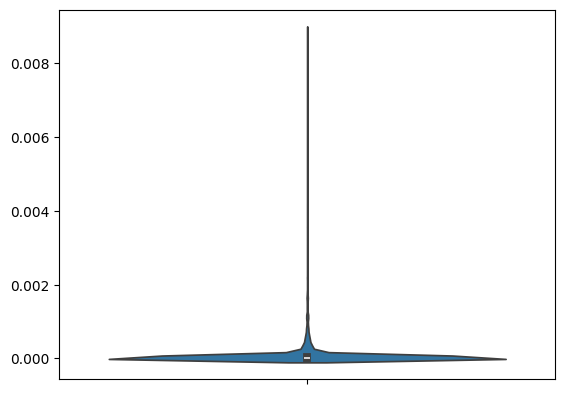

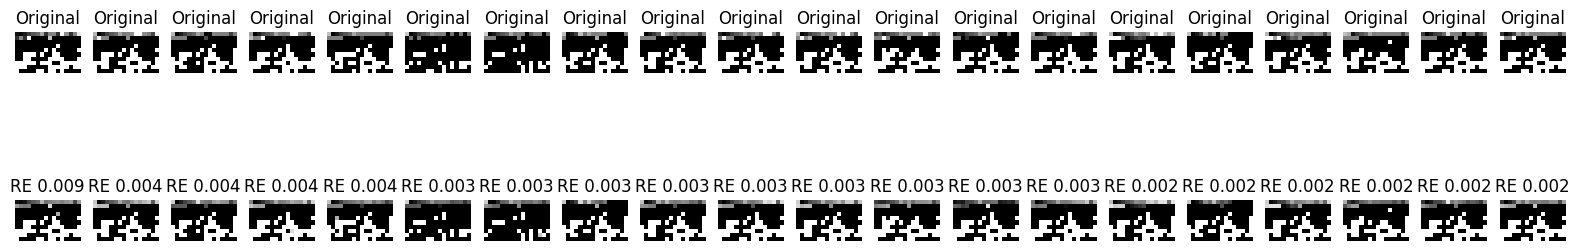

cross-val dataset: 192.168.1.169
raw dataset shape=(26365, 25)
['0000' '0005' '0010' '0017' '0023' '0033' '000B' '002B' 'FF01']


d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['0029'] will be ignored
  warnings.warn(
d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['0007', '000D', '0010', '0013', '0016', '0030', '0031', '0036', '0037', '003E', '003F', '0040', '0041', '0042', '0043', '0044', '0045', '0067', '0068', '0069', '006A', '006B', '0084', '0085', '0086', '0087', '0088', '0096', '0097', '0098', '0099', '009A', '00A0', '00A1', '00A2', '00A3', '00A4', '00A5', '0A0A', '1A1A', '2A2A', '3A3A', '4A4A', '5600', '5A5A', '6A6A', '7A7A', '8A8A', '9A9A', 'AAAA', 'BABA', 'C003', 'C004', 'C005', 'C008', 'C00D', 'C00E', 'C00F', 'C012', 'C025', 'C026', 'C029', 'C02A', 'C02D', 'C02E', 'C031', 'C032', 'CACA', 'CCAA', 'DADA', 'EAEA', 'FAFA'] will be ignored
  warnings.warn(
d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(e

(26365, 119)
824/824 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
Test reconstruction shape:
(26365,)
Number of false negatives for 1 sigma is 89 with threshold 0.00037020735799244743.
Number of true positives for 1 sigma is 26276 with threshold 0.00037020735799244743.
Number of false negatives for 2 sigma is 89 with threshold 0.0006595395021669571.
Number of true positives for 2 sigma is 26276 with threshold 0.0006595395021669571.
Number of false negatives for 3 sigma is 98 with threshold 0.0009488716463414668.
Number of true positives for 3 sigma is 26267 with threshold 0.0009488716463414668.
Reconstruction error for each sample: [0.03622998 0.02803315 0.03992025 ... 0.03436447 0.09482862 0.03149244]
Average reconstruction error: 0.036040499703813074
Min reconstruction error: 4.538605588650153e-06
Max reconstruction error: 0.4414388972501578
Worst reconstructed:


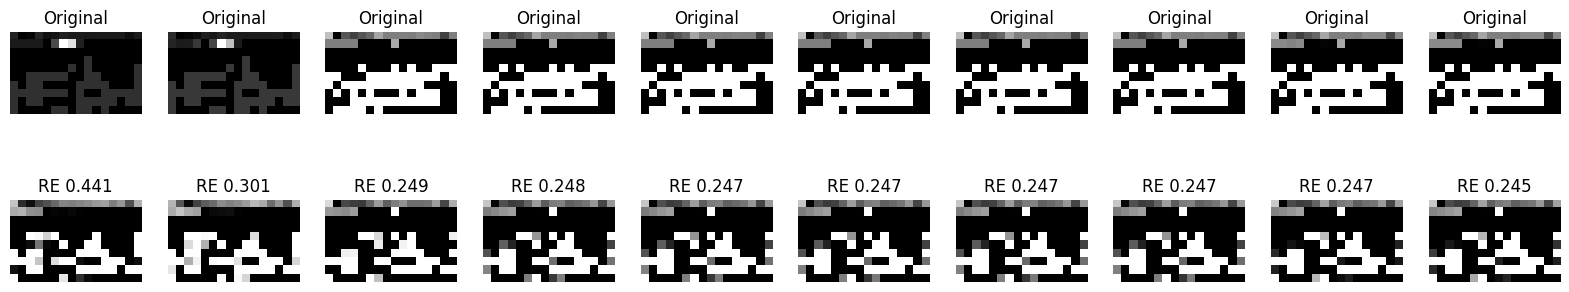

(26365, 25)
cross-val dataset: 192.168.1.172
raw dataset shape=(44492, 25)
['0000' '0005' '0010' '0017' '0023' '0033' '000B' '002B' 'FF01']


d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['0029'] will be ignored
  warnings.warn(
d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['0040', '0041', '0067', '006A', '006B', '0084', '008C', '008D', '0090', '0091', '0094', '0095', '00A2', '00A3', '00A8', '00A9', '00AA', '00AB', '00AC', '00AD', '00AE', '00AF', '00B2', '00B3', '00B6', '00B7', '0A0A', '1A1A', '2A2A', '3A3A', '4A4A', '5A5A', '6A6A', '7A7A', '8A8A', '9A9A', 'AAAA', 'BABA', 'C008', 'C012', 'C035', 'C036', 'C037', 'C038', 'C09C', 'C09D', 'C0A0', 'C0A1', 'C0AC', 'C0AD', 'C0AE', 'C0AF', 'CACA', 'CCAA', 'CCAB', 'CCAC', 'CCAD', 'CCAE', 'DADA', 'EAEA', 'FAFA'] will be ignored
  warnings.warn(
d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['0011', '0016', '0029', '002A', '0031', '0032', '0A0A', '1A1A', '2A2A', '3A3A', '44C

(44492, 119)
1391/1391 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
Test reconstruction shape:
(44492,)
Number of false negatives for 1 sigma is 40215 with threshold 0.00037020735799244743.
Number of true positives for 1 sigma is 4277 with threshold 0.00037020735799244743.
Number of false negatives for 2 sigma is 41214 with threshold 0.0006595395021669571.
Number of true positives for 2 sigma is 3278 with threshold 0.0006595395021669571.
Number of false negatives for 3 sigma is 41784 with threshold 0.0009488716463414668.
Number of true positives for 3 sigma is 2708 with threshold 0.0009488716463414668.
Reconstruction error for each sample: [1.73185975e-04 7.12171055e-05 1.26516932e-05 ... 5.04346012e-05
 7.27905218e-05 3.61770170e-05]
Average reconstruction error: 0.001272355049158492
Min reconstruction error: 2.699209662139998e-06
Max reconstruction error: 0.2823299928319724
Worst reconstructed:


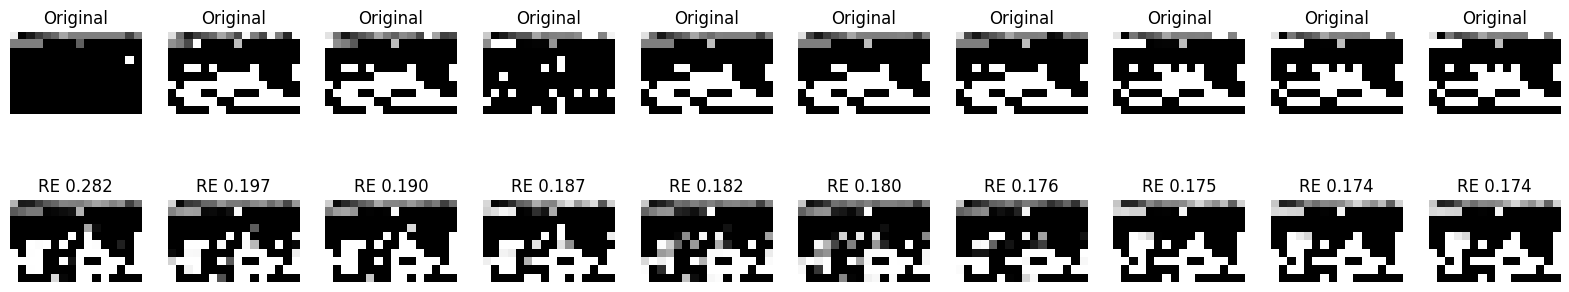

(44492, 25)
cross-val dataset: 192.168.1.174
raw dataset shape=(20091, 25)
['0000' '0005' '0010' '0017' '0023' '0033' '000B' '002B' 'FF01']


d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['0029'] will be ignored
  warnings.warn(
d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['0A0A', '1A1A', '2A2A', '3A3A', '4A4A', '5A5A', '6A6A', '7A7A', '8A8A', '9A9A', 'AAAA', 'BABA', 'C004', 'C005', 'C00E', 'C00F', 'C025', 'C026', 'C029', 'C02A', 'C02D', 'C02E', 'C031', 'C032', 'CACA', 'DADA', 'EAEA', 'FAFA'] will be ignored
  warnings.warn(
d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['0029', '002A', '0032', '0A0A', '1A1A', '2A2A', '3A3A', '44CD', '4A4A', '5A5A', '6A6A', '7A7A', '8A8A', '9A9A', 'AAAA', 'BABA', 'CACA', 'DADA', 'EAEA', 'FAFA'] will be ignored
  warnings.warn(
d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['0807'] will be ignored
  warnings.wa

(20091, 119)
628/628 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Test reconstruction shape:
(20091,)
Number of false negatives for 1 sigma is 18305 with threshold 0.00037020735799244743.
Number of true positives for 1 sigma is 1786 with threshold 0.00037020735799244743.
Number of false negatives for 2 sigma is 18770 with threshold 0.0006595395021669571.
Number of true positives for 2 sigma is 1321 with threshold 0.0006595395021669571.
Number of false negatives for 3 sigma is 19011 with threshold 0.0009488716463414668.
Number of true positives for 3 sigma is 1080 with threshold 0.0009488716463414668.
Reconstruction error for each sample: [8.67294510e-02 8.78177681e-02 4.09776049e-05 ... 8.67836036e-05
 1.30673762e-04 1.62125629e-05]
Average reconstruction error: 0.0007839710934323185
Min reconstruction error: 2.5803613927345406e-06
Max reconstruction error: 0.1598125507761682
Worst reconstructed:


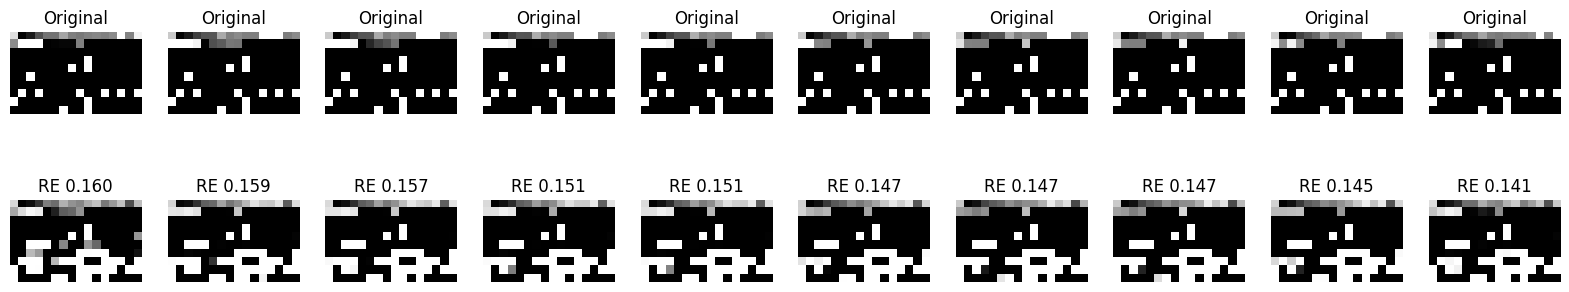

(20091, 25)
cross-val dataset: 192.168.1.181
raw dataset shape=(60253, 25)
['0000' '0005' '0010' '0017' '0023' '0033' '000B' '002B' 'FF01']


d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['0029', '3374'] will be ignored
  warnings.warn(
d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['0013', '0016', '0040', '0067', '006A', '006B', '00A2', '00A3', '0A0A', '1A1A', '2A2A', '3A3A', '4A4A', '5A5A', '6A6A', '7A7A', '8A8A', '9A9A', 'AAAA', 'BABA', 'C003', 'C004', 'C005', 'C008', 'C00D', 'C00E', 'C00F', 'C012', 'C025', 'C026', 'C029', 'C02A', 'C02D', 'C02E', 'C031', 'C032', 'CACA', 'CCAA', 'DADA', 'EAEA', 'FAFA'] will be ignored
  warnings.warn(
d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['000F', '0016', '0029', '002A', '0A0A', '1A1A', '2A2A', '3A3A', '44CD', '4A4A', '5A5A', '6A6A', '7A7A', '8A8A', '9A9A', 'AAAA', 'BABA', 'CACA', 'DADA', 'EAEA', 'FAFA', 'FF04'] will be ignored
  warnings.warn(
d:\GitHub\AutoFedProfile\.v

(60253, 119)
1883/1883 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
Test reconstruction shape:
(60253,)
Number of false negatives for 1 sigma is 51200 with threshold 0.00037020735799244743.
Number of true positives for 1 sigma is 9053 with threshold 0.00037020735799244743.
Number of false negatives for 2 sigma is 52534 with threshold 0.0006595395021669571.
Number of true positives for 2 sigma is 7719 with threshold 0.0006595395021669571.
Number of false negatives for 3 sigma is 53265 with threshold 0.0009488716463414668.
Number of true positives for 3 sigma is 6988 with threshold 0.0009488716463414668.
Reconstruction error for each sample: [4.70327648e-05 5.96538295e-04 2.27249479e-05 ... 3.38364015e-02
 3.22351110e-02 1.38469281e-05]
Average reconstruction error: 0.003531839799927528
Min reconstruction error: 2.7416735702203882e-06
Max reconstruction error: 0.2232108040610612
Worst reconstructed:


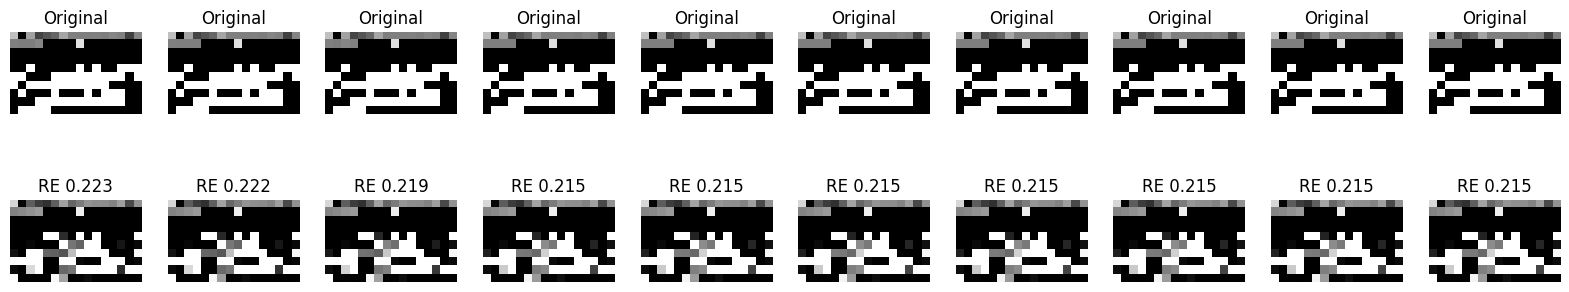

(60253, 25)
cross-val dataset: 192.168.1.185
raw dataset shape=(8579, 25)
['0000' '0005' '0010' '0017' '0023' '0033' '000B' '002B' 'FF01']


d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['0029'] will be ignored
  warnings.warn(
d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['0067', '006B', '0A0A', '1A1A', '2A2A', '3A3A', '4A4A', '5A5A', '6A6A', '7A7A', '8A8A', '9A9A', 'AAAA', 'BABA', 'C09C', 'C09D', 'C09E', 'C09F', 'C0AC', 'C0AD', 'CACA', 'DADA', 'EAEA', 'FAFA'] will be ignored
  warnings.warn(
d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['0016', '0029', '002A', '0A0A', '1A1A', '2A2A', '3A3A', '44CD', '4A4A', '5A5A', '6A6A', '7A7A', '8A8A', '9A9A', 'AAAA', 'BABA', 'CACA', 'DADA', 'EAEA', 'FAFA'] will be ignored
  warnings.warn(
d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['0807', '0808', '0809', '080A', '080B', '081A', '081B', '081C'] will 

(8579, 119)
269/269 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Test reconstruction shape:
(8579,)
Number of false negatives for 1 sigma is 2738 with threshold 0.00037020735799244743.
Number of true positives for 1 sigma is 5841 with threshold 0.00037020735799244743.
Number of false negatives for 2 sigma is 2909 with threshold 0.0006595395021669571.
Number of true positives for 2 sigma is 5670 with threshold 0.0006595395021669571.
Number of false negatives for 3 sigma is 2963 with threshold 0.0009488716463414668.
Number of true positives for 3 sigma is 5616 with threshold 0.0009488716463414668.
Reconstruction error for each sample: [1.03910874e-03 1.15106140e-05 2.44889674e-05 ... 1.29051019e-02
 2.36132063e-05 1.14475052e-02]
Average reconstruction error: 0.012088947472925363
Min reconstruction error: 5.322731152284917e-06
Max reconstruction error: 0.27635770977457985
Worst reconstructed:


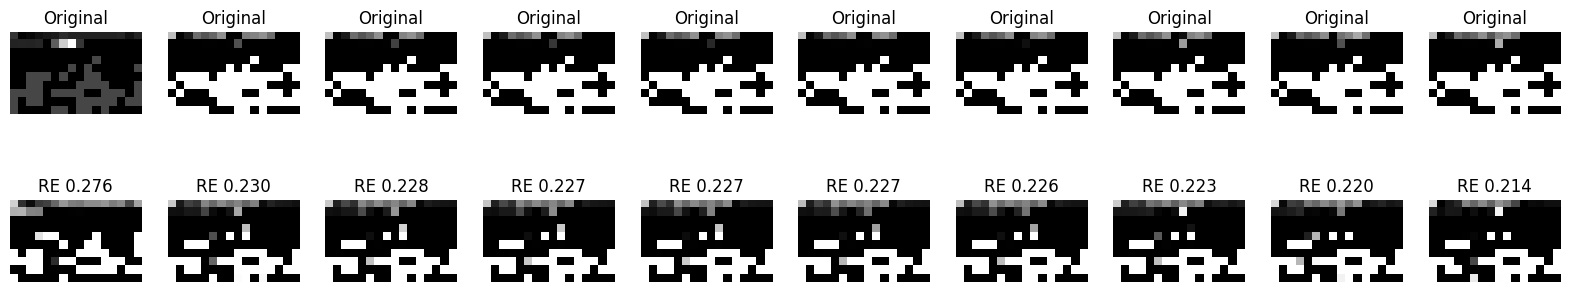

(8579, 25)
cross-val dataset: 192.168.1.197
raw dataset shape=(227962, 25)


d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['0029'] will be ignored
  warnings.warn(


['0000' '0005' '0010' '0017' '0023' '0033' '000B' '002B' 'FF01']


d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['0A0A', '1A1A', '2A2A', '3A3A', '4A4A', '5600', '5A5A', '6A6A', '7A7A', '8A8A', '9A9A', 'AAAA', 'BABA', 'C008', 'C012', 'CACA', 'DADA', 'EAEA', 'FAFA'] will be ignored
  warnings.warn(
d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['0014', '0029', '0A0A', '1A1A', '2A2A', '3A3A', '44CD', '4A4A', '5A5A', '6A6A', '7A7A', '8A8A', '9A9A', 'AAAA', 'BABA', 'CACA', 'DADA', 'EAEA', 'FAFA'] will be ignored
  warnings.warn(
d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['apns-pack-v1', 'apns-security-v3', 'dot', 'grpc-exp', 'http/1.0'] will be ignored
  warnings.warn(
d:\GitHub\AutoFedProfile\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['0301', '0302', '0A0A', '1A1A', '2A2A', '3A3A', '4A4A', '5

(227962, 119)
7124/7124 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step
Test reconstruction shape:
(227962,)
Number of false negatives for 1 sigma is 30104 with threshold 0.00037020735799244743.
Number of true positives for 1 sigma is 197858 with threshold 0.00037020735799244743.
Number of false negatives for 2 sigma is 33659 with threshold 0.0006595395021669571.
Number of true positives for 2 sigma is 194303 with threshold 0.0006595395021669571.
Number of false negatives for 3 sigma is 37783 with threshold 0.0009488716463414668.
Number of true positives for 3 sigma is 190179 with threshold 0.0009488716463414668.
Reconstruction error for each sample: [0.01163833 0.02340526 0.01309601 ... 0.02874413 0.00013959 0.00764668]
Average reconstruction error: 0.04424252526855756
Min reconstruction error: 4.399515352758128e-06
Max reconstruction error: 1.8253863830920407
Worst reconstructed:


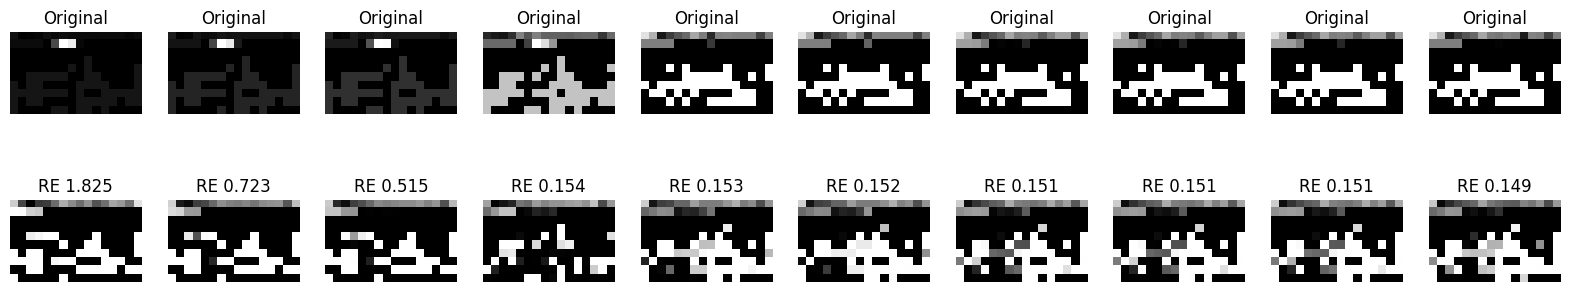

(227962, 25)

🌀 Fold 5/10
train shape=(41760, 157)
test shape=(4640, 157)
Epoch 1/100
 347/1305 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.2862

In [ ]:
from tensorflow.keras.layers import Input, Dense, Conv1D, MaxPooling1D, Flatten, Lambda, Concatenate
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Model
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns
from viz_helper import make_image_from_sample
 
LATENT_SPACE_SIZE=10

#sequential interleaved k-fold split
def interleaved_kfold_df(df, k):
    """
    Returns a list of (train_idx, val_idx) tuples using interleaved k-fold.
    These are index arrays you can use to extract rows from the original df.
    """
    n_samples = len(df)
    all_indices = np.arange(n_samples)
    fold_indices = [all_indices[i::k] for i in range(k)]

    folds = []
    for i in range(k):
        val_idx = fold_indices[i]
        print(f'Validation set indices: {val_idx}')
        train_idx = np.hstack([fold_indices[j] for j in range(k) if j != i])
        folds.append((train_idx, val_idx))
    
    return folds


def autoencoder_training(x_train, x_test) -> Model:
    # 1. Dataset split done in advance to ensure k-fold cross validation
    print(f'train shape={x_train.shape}')
    print(f'test shape={x_test.shape}')
    
    # 2. Define dimensions and architecture
    input_dim = x_train.shape[1]
    encoding_dim = LATENT_SPACE_SIZE  # Size of the latent space
        
    conv_input_size = 20
    intermediate_dim = 64
    
    # Input placeholder
    input_img = Input(shape=(input_dim,))
    # Slice the first 20 values for convolution
    def slice_first_20(x):
        return tf.reshape(x[:, :conv_input_size], (-1, conv_input_size, 1))  # shape: (batch, steps, channels)
    sliced_input = Lambda(slice_first_20, output_shape=(conv_input_size, 1))(input_img)
    
    # Convolutional processing
    conv_layer = Conv1D(filters=32, kernel_size=3, activation='relu')(sliced_input)
    pool_layer = MaxPooling1D(pool_size=2)(conv_layer)
    flattened_conv = Flatten()(pool_layer)
    
    # Remaining input: slice from index 20 onward
    def slice_remaining(x):
        return x[:, conv_input_size:]
    
    remaining_input = Lambda(slice_remaining, output_shape=(input_dim - conv_input_size,))(input_img)
    dense_input = Dense(intermediate_dim, activation='relu')(remaining_input)
    
    # Combine processed convolutional and dense features
    combined = Concatenate()([flattened_conv, dense_input])
    # Encoder layers
    hidden = Dense(intermediate_dim, activation='relu')(combined)
    encoded = Dense(encoding_dim, activation='relu')(hidden)
    
    # Decoder layers
    hidden_decoded = Dense(intermediate_dim, activation='relu')(encoded)
    decoded = Dense(input_dim, activation='sigmoid')(hidden_decoded)
    
    # Autoencoder model
    autoencoder = Model(input_img, decoded)
    
    # Encoder model for later use
    encoder = Model(input_img, encoded)
    
    # Decoder model setup
    encoded_input = Input(shape=(encoding_dim,))
    decoder_layer1 = autoencoder.layers[-2](encoded_input)
    decoder_layer2 = autoencoder.layers[-1](decoder_layer1)  #zde bylo -1
    decoder = Model(encoded_input, decoder_layer2)
    
    # 3. Compile and train the autoencoder
    autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
    autoencoder.fit(x_train, x_train, validation_data=(x_test, x_test), epochs=100)
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    autoencoder.fit(x_train, x_train,
                    epochs=500,                      # use some more reasonable number here (>50)
                    callbacks = [early_stop],
                    batch_size=16,
                    shuffle=True,                
                    validation_data=(x_test, x_test))
    
    # 4. Visualize the reconstructed images
    encoded_imgs = encoder.predict(x_test)
    decoded_imgs = decoder.predict(encoded_imgs)
    
    # Assuming x_test contains the original test data
    # and decoded_imgs are the autoencoder's reconstructed outputs
    reconstruction_errors = np.mean(np.square(x_test - decoded_imgs), axis=1)
    
    # Average reconstruction error across all samples
    avg_error = np.mean(reconstruction_errors)
    max_error = np.max(reconstruction_errors)
    min_error = np.min(reconstruction_errors)
    std_error = np.std(reconstruction_errors)
    print(f"Reconstruction error for each sample {reconstruction_errors}")
    print(f"Average={avg_error}, Max={max_error}, Min={min_error} reconstruction errors.")
    print(f"Standard deviation of reconstruction error = {std_error}.")
    
    #false positives evaluation
    FP_1_sigma = np.sum(reconstruction_errors > (avg_error + 1*std_error))
    print(f"Number of false positives for 1 sigma is {FP_1_sigma} with threshold {avg_error + 1*std_error}.")
    FP_2_sigma = np.sum(reconstruction_errors > (avg_error + 2*std_error))
    print(f"Number of false positives for 2 sigma is {FP_2_sigma}.")
    FP_3_sigma = np.sum(reconstruction_errors > (avg_error + 3*std_error))
    print(f"Number of false positives for 3 sigma is {FP_3_sigma}.")
    
    
    sns.violinplot(data= reconstruction_errors)
    
    # Get indices that would sort the array in ascending order
    worst20 = np.argsort(reconstruction_errors)[-20:][::-1]
    worst50 = np.argsort(reconstruction_errors)[-50:][::-1]
    
    n = 20  # Number of digits to display
    i = 0
    
    print("Worst reconstructed:")
    plt.figure(figsize=(20, 4))
    for j in worst20:
        reconstruction_error = reconstruction_errors[j]
        original = x_test[j]
        original = make_image_from_sample(original) 
        reconstructed = decoded_imgs[j]
        reconstructed = make_image_from_sample(reconstructed) 
        # Original images
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(original, cmap='gray')
        plt.title("Original")
        plt.axis('off')
        
        # Reconstructed images
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(reconstructed, cmap='gray')
        plt.title(f"RE {reconstruction_error:.3f}")
        plt.axis('off')
        i+=1
    plt.show()

    return autoencoder, avg_error, std_error

def test_dataset(model: Model, avg_error, std_error, json_files):
    raw_test_df = load_json_files(json_files)
    raw_test_df = raw_test_df.rename(columns={'te': 'td'})
    print(f'raw dataset shape={raw_test_df.shape}')
    input_test_df = extract_features(raw_test_df)
    test_df = pipeline.transform(input_test_df)

    decoded_test = model.predict(test_df)

    # Assuming x_test contains the original test data
    # and decoded_imgs are the autoencoder's reconstructed outputs
    test_reconstruction_errors = np.mean(np.square(test_df - decoded_test), axis=1)
    print("Test reconstruction shape:")
    print(test_reconstruction_errors.shape)
    
    #Find numbers of FN a TP for different tresholds
    FN_1_sigma = np.sum(test_reconstruction_errors < (avg_error + 1*std_error))
    print(f"Number of false negatives for 1 sigma is {FN_1_sigma} with threshold {avg_error + 1*std_error}.")
    TP_1_sigma = np.sum(test_reconstruction_errors > (avg_error + 1*std_error))
    print(f"Number of true positives for 1 sigma is {TP_1_sigma} with threshold {avg_error + 1*std_error}.")    
    FN_2_sigma = np.sum(test_reconstruction_errors < (avg_error + 2*std_error))
    print(f"Number of false negatives for 2 sigma is {FN_2_sigma} with threshold {avg_error + 2*std_error}.")
    TP_2_sigma = np.sum(test_reconstruction_errors > (avg_error + 2*std_error))
    print(f"Number of true positives for 2 sigma is {TP_2_sigma} with threshold {avg_error + 2*std_error}.")   
    FN_3_sigma = np.sum(test_reconstruction_errors < (avg_error + 3*std_error))
    print(f"Number of false negatives for 3 sigma is {FN_3_sigma} with threshold {avg_error + 3*std_error}.")
    TP_3_sigma = np.sum(test_reconstruction_errors > (avg_error + 3*std_error))
    print(f"Number of true positives for 3 sigma is {TP_3_sigma} with threshold {avg_error + 3*std_error}.")   
       
    # Get indices that would sort the array in ascending order
    worst10 = np.argsort(test_reconstruction_errors)[-10:][::-1]
    worst50 = np.argsort(test_reconstruction_errors)[-50:][::-1]

    # Average reconstruction error across all samples
    test_avg_error = np.mean(test_reconstruction_errors)
    test_min_error = np.min(test_reconstruction_errors)
    test_max_error = np.max(test_reconstruction_errors)
    print("Reconstruction error for each sample:", test_reconstruction_errors)
    print("Average reconstruction error:", test_avg_error)
    print("Min reconstruction error:", test_min_error)
    print("Max reconstruction error:", test_max_error)
    print("Worst reconstructed:")
    n = 10  # Number of digits to display
    i = 0
    plt.figure(figsize=(20, 4))
    for j in worst10:
        rec_error = test_reconstruction_errors[j]       
        original = test_df[j]
        original = make_image_from_sample(original)  
        reconstructed = decoded_test[j]
        reconstructed = make_image_from_sample(reconstructed)
        # Original images
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(original, cmap='gray')
        plt.title("Original")
        plt.axis('off')
        
        # Reconstructed images
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(reconstructed, cmap='gray')
        plt.title(f"RE {rec_error:.3f}")
        plt.axis('off')
        i+=1
    plt.show()
    print(raw_test_df.shape)



k = 10
folds = interleaved_kfold_df(normal_df, k)
_, val_idx = folds[-1]
last_val_df = raw_df.iloc[val_idx]

# Save it to CSV
#last_val_df.to_csv('last_validation_set.csv', index=False)
#last_val_df.to_csv('val9.csv')

for fold_idx, (train_idx, test_idx) in enumerate(folds):
    print(f"\n🌀 Fold {fold_idx + 1}/{k}")
    x_train = normal_df[train_idx]
    x_test = normal_df[test_idx]
    autoencoder, avg_error, std_error = autoencoder_training(x_train,x_test)
    print("cross-val dataset: 192.168.1.169")
    test_dataset(autoencoder, avg_error, std_error, json_files=glob.glob(f"{dataset_root}/BUT-SOHO2025/192.168.1.169/*.ndjson"))
    print("cross-val dataset: 192.168.1.172")
    test_dataset(autoencoder, avg_error, std_error, json_files=glob.glob(f"{dataset_root}/BUT-SOHO2025/192.168.1.172/*.ndjson"))   
    print("cross-val dataset: 192.168.1.174")
    test_dataset(autoencoder, avg_error, std_error, json_files=glob.glob(f"{dataset_root}/BUT-SOHO2025/192.168.1.174/*.ndjson"))    
    print("cross-val dataset: 192.168.1.181")
    test_dataset(autoencoder, avg_error, std_error, json_files=glob.glob(f"{dataset_root}/BUT-SOHO2025/192.168.1.181/*.ndjson"))    
    print("cross-val dataset: 192.168.1.185")
    test_dataset(autoencoder, avg_error, std_error, json_files=glob.glob(f"{dataset_root}/BUT-SOHO2025/192.168.1.185/*.ndjson"))
    print("cross-val dataset: 192.168.1.197")
    test_dataset(autoencoder, avg_error, std_error, json_files=glob.glob(f"{dataset_root}/BUT-SOHO2025/192.168.1.197/*.ndjson"))
    #print("cross-val dataset: 192.168.1.198")
    #test_dataset(autoencoder, avg_error, std_error, json_files=glob.glob(f"{dataset_root}/BUT-SOHO2025/192.168.1.198/*.ndjson"))